<a href="https://colab.research.google.com/github/Nicokac/Cartera/blob/main/Cartera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Análisis de Portafolio — IOL + Finviz

**Módulos:**
- ⚙️ Módulo 1 — Setup e instalación
- ⚙️ Módulo 2 — Configuración: portafolio, ratios y umbrales
- 🔄 Módulo 3 — Fetch de datos (Finviz) — *ejecutar una sola vez*
- 📋 Módulo 4 — Dashboard ejecutivo (KPIs, bloques, top 5, alertas)
- 💼 Módulo 5 — Portafolio IOL detallado (MEP, valor USD, ganancias)
- 📊 Módulo 6 — Fundamentals (tabla, heatmap, P/E, Beta)
- ⭐ Módulo 7 — Ratings de analistas
- 📰 Módulo 8 — Noticias recientes
- 🕵️ Módulo 9 — Operaciones de insiders

> **Flujo recomendado:** ejecutar en orden (Run All) o por módulo.  
> El Módulo 3 hace el fetch completo (~3–4 min). Los módulos 4–9 solo visualizan los datos ya cargados.  
> La lógica canónica del proyecto vive en `src/`; este notebook queda como interfaz de uso y exploración.  

---

## ⚙️ Módulo 1 — Setup e instalación

In [1]:
# Celda 1
# Dependencias base
%pip install pandas numpy jinja2 --quiet

# Fuentes de datos
%pip install finvizfinance yfinance --quiet

# Visualización
%pip install matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Celda 2
import time
import warnings
from datetime import datetime, timedelta
from getpass import getpass

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from finvizfinance.quote import finvizfinance

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


---
## ⚙️ Módulo 2 — Configuración

Editá `PORTAFOLIO`, `RATIOS` y los umbrales de alerta cuando actualices tu cartera o cuando BYMA/CNV modifique algún ratio.  
Verificar ratios en: [byma.com.ar/cedears](https://www.byma.com.ar/cedears/)

In [3]:
# Celda 3
from datetime import datetime
from pathlib import Path
from zoneinfo import ZoneInfo
import sys

PROJECT_ROOT = Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import config as project_config
from clients.argentinadatos import get_mep_real
from clients.iol import (
    iol_get_estado_cuenta as client_iol_get_estado_cuenta,
    iol_get_portafolio as client_iol_get_portafolio,
    iol_get_quote as client_iol_get_quote,
    iol_get_quote_with_reauth as client_iol_get_quote_with_reauth,
    iol_login as client_iol_login,
)
from analytics.dashboard import build_executive_dashboard_data
from pipeline import build_dashboard_bundle, build_decision_bundle, build_portfolio_bundle, build_sizing_bundle
from decision.actions import assign_action_v2, assign_base_action, enrich_decision_explanations
from decision.scoring import (
    apply_base_scores,
    apply_technical_overlay_scores,
    build_decision_base,
    consensus_to_score,
    finalize_unified_score,
    rank_score,
)
from decision.sizing import build_dynamic_allocation, build_operational_proposal, build_prudent_allocation
from portfolio.classify import classify_iol_portfolio
from portfolio.checks import build_integrity_report
from portfolio.liquidity import rebuild_liquidity
from portfolio.valuation import (
    build_bonos_df,
    build_cedears_df,
    build_local_df,
    build_portfolio_master,
)

IOL_BASE_URL = project_config.IOL_BASE_URL
MARKET = project_config.MARKET
print("✅ Configuración base cargada desde src/config.py")

from datetime import datetime
from zoneinfo import ZoneInfo


# Revalidar MEP con el cliente canónico durante la transición
def iol_login(username, password):
    resp = requests.post(
        f"{IOL_BASE_URL}/token",
        data={
            "username": username,
            "password": password,
            "grant_type": "password"
        },
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()["access_token"]


def iol_get_quote(symbol, token):
    resp = requests.get(
        f"{IOL_BASE_URL}/api/v2/{MARKET}/Titulos/{symbol}/CotizacionDetalle",
        headers={"Authorization": f"Bearer {token}"},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()


use_iol_input = input("¿Querés usar una cuenta de IOL? (s/n): ").strip().lower()
# Usar cliente IOL canónico durante la transición
iol_login = lambda username, password: client_iol_login(username, password, base_url=IOL_BASE_URL)
iol_get_quote = lambda symbol, token: client_iol_get_quote(symbol, token, base_url=IOL_BASE_URL, market=MARKET)
USE_IOL = use_iol_input == "s"
print("âœ… Bootstrap del notebook enlazado a src/ y src/pipeline.py")

if USE_IOL:
    from getpass import getpass

    IOL_USERNAME = getpass("Usuario IOL: ").strip()
    IOL_PASSWORD = getpass("Password IOL: ").strip()

    if not IOL_USERNAME:
        raise ValueError("IOL_USERNAME no puede estar vacío.")
    if not IOL_PASSWORD:
        raise ValueError("IOL_PASSWORD no puede estar vacío.")

    access_token = iol_login(IOL_USERNAME, IOL_PASSWORD)

    hora_argentina = datetime.now(ZoneInfo("America/Argentina/Buenos_Aires"))
    print(f"✅ Login IOL exitoso — {hora_argentina.strftime('%H:%M:%S')}")
else:
    access_token = None
    print("ℹ️ IOL no será utilizado. Continuando sin autenticación.")

✅ Configuración base cargada desde src/config.py
âœ… Bootstrap del notebook enlazado a src/ y src/pipeline.py
✅ Login IOL exitoso — 01:08:00


In [4]:
# Celda 4 final — traer portafolio real desde IOL y enriquecerlo

def iol_get_portafolio(token, pais="argentina"):
    resp = requests.get(
        f"{IOL_BASE_URL}/api/v2/portafolio/{pais}",
        headers={"Authorization": f"Bearer {token}"},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()

def iol_get_estado_cuenta(token):
    resp = requests.get(
        f"{IOL_BASE_URL}/api/v2/estadocuenta",
        headers={"Authorization": f"Bearer {token}"},
        timeout=30
    )
    resp.raise_for_status()
    return resp.json()

# ── Enriquecimiento local que IOL no trae como vos lo necesitás ───────────────
FINVIZ_MAP = {
    'SPY': 'SPY', 'AAPL': 'AAPL', 'T': 'T', 'MELI': 'MELI', 'IEUR': 'IEUR',
    'AMZN': 'AMZN', 'NEM': 'NEM', 'EWZ': 'EWZ', 'EEM': 'EEM', 'KO': 'KO',
    'VIST': 'VIST', 'NVDA': 'NVDA', 'V': 'V', 'BRKB': 'BRK-B', 'GOOGL': 'GOOGL',
    'MCD': 'MCD', 'XLV': 'XLV', 'MSFT': 'MSFT', 'XLU': 'XLU', 'CRM': 'CRM',
    'DIA': 'DIA', 'DISN': 'DIS', 'BABA': 'BABA', 'AMD': 'AMD',
}

BLOCK_MAP = {
    'SPY': 'Core', 'AAPL': 'Growth', 'T': 'Dividendos', 'MELI': 'Growth',
    'IEUR': 'Europa', 'AMZN': 'Growth', 'NEM': 'Commodities', 'EWZ': 'Brasil',
    'EEM': 'Emergentes', 'KO': 'Dividendos', 'VIST': 'Commodities',
    'NVDA': 'Growth', 'V': 'Growth', 'BRKB': 'Defensivo', 'GOOGL': 'Growth',
    'MCD': 'Dividendos', 'XLV': 'Defensivo', 'MSFT': 'Growth', 'XLU': 'Defensivo',
    'CRM': 'Growth', 'DIA': 'Core', 'DISN': 'Growth', 'BABA': 'Growth', 'AMD': 'Growth',
    'YPFD': 'Commodities', 'LOMA': 'Argentina', 'TECO2': 'Argentina',
    'GD30': 'Soberano AR', 'AL30': 'Soberano AR', 'BPOC7': 'Bopreal',
    'GD35': 'Soberano AR', 'TZX26': 'CER', 'TZXM6': 'CER',
    'ADBAICA': 'Liquidez', 'IOLPORA': 'Liquidez', 'PRPEDOB': 'Liquidez',
    'CAUCIÓN COLOCADORA': 'Liquidez',
}

RATIOS = {
    'SPY': 20, 'AAPL': 20, 'T': 3, 'MELI': 120,
    'IEUR': 11, 'AMZN': 144, 'NEM': 3, 'EWZ': 2,
    'EEM': 5, 'KO': 5, 'VIST': 3, 'NVDA': 24,
    'V': 18, 'BRKB': 22, 'GOOGL': 58, 'MCD': 24,
    'XLV': 29, 'MSFT': 30, 'XLU': 15, 'CRM': 18,
    'DIA': 20, 'DISN': 12, 'BABA': 9, 'AMD': 10,
}

VN_FACTOR_MAP = {
    'GD30': 100,
    'AL30': 100,
    'BPOC7': 100,
    'GD35': 100,
    'TZX26': 100,
    'TZXM6': 100,
}

ARGENTINADATOS_URL = "https://api.argentinadatos.com/v1/cotizaciones/dolares/{casa}"
MEP_CASA = "bolsa"

ALERTA_MEP_DESVIO_PCT = 5
ALERTA_PERDIDA_MINIMA = -10000

# Reemplazar hardcodes por la configuración canónica del proyecto
FINVIZ_MAP = project_config.FINVIZ_MAP.copy()
BLOCK_MAP = project_config.BLOCK_MAP.copy()
RATIOS = project_config.RATIOS.copy()
VN_FACTOR_MAP = project_config.VN_FACTOR_MAP.copy()
ARGENTINADATOS_URL = project_config.ARGENTINADATOS_URL
MEP_CASA = project_config.MEP_CASA
ALERTA_MEP_DESVIO_PCT = project_config.ALERTA_MEP_DESVIO_PCT
ALERTA_PERDIDA_MINIMA = project_config.ALERTA_PERDIDA_MINIMA
print("✅ Mappings y parámetros cargados desde data/mappings/ y src/config.py")

# ── 1. Traer datos reales desde IOL ───────────────────────────────────────────
# Usar cliente IOL canónico durante la transición
iol_get_portafolio = lambda token, pais="argentina": client_iol_get_portafolio(token, base_url=IOL_BASE_URL, pais=pais)
iol_get_estado_cuenta = lambda token: client_iol_get_estado_cuenta(token, base_url=IOL_BASE_URL)
portfolio_payload = iol_get_portafolio(access_token, pais="argentina")
estado_payload = iol_get_estado_cuenta(access_token)

activos = portfolio_payload.get("activos", [])
print(f"✅ Activos recibidos desde IOL: {len(activos)}")

# ── 2. Clasificar posiciones ──────────────────────────────────────────────────
PORTAFOLIO = []
ACCIONES_LOCALES = []
BONOS = []
LIQUIDEZ = []

for activo in activos:
    titulo = activo.get("titulo", {}) or {}
    simbolo = titulo.get("simbolo")
    descripcion = titulo.get("descripcion")
    tipo = str(titulo.get("tipo") or "").strip()
    tipo_norm = tipo.upper().replace(" ", "")
    moneda = str(titulo.get("moneda") or "")

    cantidad = float(activo.get("cantidad", 0) or 0)
    ppc = float(activo.get("ppc", 0) or 0)
    valorizado = float(activo.get("valorizado", 0) or 0)
    ganancia_dinero = float(activo.get("gananciaDinero", 0) or 0)

    if not simbolo:
        continue

    bloque = BLOCK_MAP.get(simbolo, "Sin clasificar")

    # CEDEARs
    if tipo_norm == "CEDEARS":
        ticker_finviz = FINVIZ_MAP.get(simbolo)
        if ticker_finviz:
            PORTAFOLIO.append((simbolo, ticker_finviz, bloque, cantidad, ppc))
        continue

    # Acciones locales
    if tipo_norm in {"ACCIONES", "ACCION"}:
        ACCIONES_LOCALES.append((simbolo, simbolo, bloque, cantidad, ppc))
        continue

    # Bonos / títulos públicos
    if tipo_norm in {"TITULOSPUBLICOS", "TITULOPUBLICO"}:
        vn_factor = VN_FACTOR_MAP.get(simbolo, 100)
        BONOS.append((simbolo, bloque, cantidad, ppc, vn_factor))
        continue

    # FCI / cash management
    if "FONDOCOMUNDEINVERSION" in tipo_norm or "FCI" in tipo_norm:
        LIQUIDEZ.append((
            simbolo,
            descripcion,
            "Liquidez",
            "USD" if "DOLAR" in descripcion.upper() or "USD" in moneda.upper() else "ARS",
            valorizado,
            ganancia_dinero
        ))
        continue

    # Caución
    if "CAUCION" in tipo_norm:
        LIQUIDEZ.append((
            "CAUCION",
            descripcion,
            "Liquidez",
            "ARS",
            valorizado,
            ganancia_dinero
        ))
        continue

# ── 3. Orden opcional para dejar salida consistente ───────────────────────────
PORTAFOLIO = sorted(PORTAFOLIO, key=lambda x: x[0])
ACCIONES_LOCALES = sorted(ACCIONES_LOCALES, key=lambda x: x[0])
BONOS = sorted(BONOS, key=lambda x: x[0])
LIQUIDEZ = sorted(LIQUIDEZ, key=lambda x: x[0])

print("✅ Configuración cargada desde IOL")
print(f"   CEDEARs:          {len(PORTAFOLIO)}")
print(f"   Acciones locales: {len(ACCIONES_LOCALES)}")
print(f"   Bonos:            {len(BONOS)}")
print(f"   Liquidez:         {len(LIQUIDEZ)}")

# Recalcular clasificación con la ruta canónica de src/portfolio/
classification = classify_iol_portfolio(
    activos,
    finviz_map=FINVIZ_MAP,
    block_map=BLOCK_MAP,
    vn_factor_map=VN_FACTOR_MAP,
)
PORTAFOLIO = classification["PORTAFOLIO"]
ACCIONES_LOCALES = classification["ACCIONES_LOCALES"]
BONOS = classification["BONOS"]
LIQUIDEZ = classification["LIQUIDEZ"]


✅ Mappings y parámetros cargados desde data/mappings/ y src/config.py
✅ Activos recibidos desde IOL: 38
✅ Configuración cargada desde IOL
   CEDEARs:          24
   Acciones locales: 3
   Bonos:            7
   Liquidez:         4


In [5]:
# Celda 5
# Debug rápido de tipos reales que devuelve IOL
debug_rows = []

for activo in activos:
    titulo = activo.get("titulo", {}) or {}
    debug_rows.append({
        "simbolo": titulo.get("simbolo"),
        "descripcion": titulo.get("descripcion"),
        "tipo": titulo.get("tipo"),
        "moneda": titulo.get("moneda"),
        "cantidad": activo.get("cantidad"),
        "valorizado": activo.get("valorizado"),
    })

df_debug_iol = pd.DataFrame(debug_rows)
display(df_debug_iol.sort_values(["tipo", "simbolo"]))
print(df_debug_iol["tipo"].value_counts(dropna=False))


,simbolo,descripcion,tipo,moneda,cantidad,valorizado
20,LOMA,Loma Negra Compañia Industrial Argentina Sa,ACCIONES,peso_Argentino,35.00,116200.00
29,TECO2,Telecom Argentina,ACCIONES,peso_Argentino,21.00,73500.00
37,YPFD,Ypf,ACCIONES,peso_Argentino,6.00,392700.00
8,CAUCIÓN COLOCADORA,Caución En Pesos,CAUCIONESPESOS,peso_Argentino,0.00,7574463.66
0,AAPL,Cedear Apple Inc.,CEDEARS,peso_Argentino,64.00,1215360.00
3,AMD,"Cedear Advanced Micro Devices,",CEDEARS,peso_Argentino,1.00,31200.00
4,AMZN,"Cedear Amazon.Com, Inc",CEDEARS,peso_Argentino,350.00,763350.00
5,BABA,Cedear Alibaba Group Holding L,CEDEARS,peso_Argentino,2.00,40940.00
7,BRKB,Cedear Berkshire Hathaway Inc.,CEDEARS,peso_Argentino,6.00,194280.00
9,CRM,Cedear Salesforce Inc,CEDEARS,peso_Argentino,7.00,107310.00


tipo
CEDEARS                  24
TitulosPublicos           7
FondoComundeInversion     3
ACCIONES                  3
CAUCIONESPESOS            1
Name: count, dtype: int64


In [ ]:
# Celda 6 — reconstrucción de liquidez al estilo del proyecto local

import numpy as np
import pandas as pd

mep_real = globals().get('mep_real', None)
FCI_CASH_MANAGEMENT = project_config.FCI_CASH_MANAGEMENT.copy()

def normalize_account_currency(moneda):
    m = str(moneda or '').strip().upper()
    if 'DOLAR' in m or 'USD' in m:
        return 'USD'
    return 'ARS'

def extract_estado_cuenta_components(estado_payload):
    cash_immediate_ars = 0.0
    cash_immediate_usd = 0.0
    cash_pending_ars = 0.0
    cash_pending_usd = 0.0
    fallback_cash_ars = 0.0
    fallback_cash_usd = 0.0
    total_broker_en_pesos = float(estado_payload.get('totalEnPesos', 0) or 0)

    for cuenta in estado_payload.get('cuentas', []):
        moneda = normalize_account_currency(cuenta.get('moneda'))
        disponible = float(cuenta.get('disponible', 0) or 0)

        if moneda == 'ARS':
            fallback_cash_ars += disponible
        else:
            fallback_cash_usd += disponible

        saldos = cuenta.get('saldos', []) or []
        if not saldos:
            continue

        immediate_found = False

        for saldo_row in saldos:
            liquidacion = str(saldo_row.get('liquidacion') or '').strip().lower()
            disponible_row = float(saldo_row.get('disponible', 0) or 0)

            if liquidacion == 'inmediato':
                immediate_found = True
                if moneda == 'ARS':
                    cash_immediate_ars += disponible_row
                else:
                    cash_immediate_usd += disponible_row
            else:
                if moneda == 'ARS':
                    cash_pending_ars += disponible_row
                else:
                    cash_pending_usd += disponible_row

        if not immediate_found:
            if moneda == 'ARS':
                cash_immediate_ars += disponible
            else:
                cash_immediate_usd += disponible

    if cash_immediate_ars == 0 and fallback_cash_ars > 0:
        cash_immediate_ars = fallback_cash_ars
    if cash_immediate_usd == 0 and fallback_cash_usd > 0:
        cash_immediate_usd = fallback_cash_usd

    return {
        'cash_immediate_ars': cash_immediate_ars,
        'cash_immediate_usd': cash_immediate_usd,
        'cash_pending_ars': cash_pending_ars,
        'cash_pending_usd': cash_pending_usd,
        'cash_disponible_ars': fallback_cash_ars,
        'cash_disponible_usd': fallback_cash_usd,
        'total_broker_en_pesos': total_broker_en_pesos,
    }

# ── 1. Reconstruir liquidez desde portafolio + estado de cuenta ──────────────
LIQUIDEZ = []

caucion_ars = 0.0
fci_cash_management_ars = 0.0

for activo in activos:
    titulo = activo.get("titulo", {}) or {}
    simbolo = str(titulo.get("simbolo") or "").strip()
    descripcion = str(titulo.get("descripcion") or "").strip()
    tipo = str(titulo.get("tipo") or "").strip()
    tipo_norm = tipo.upper().replace(" ", "")
    moneda_raw = str(titulo.get("moneda") or "")
    moneda = normalize_account_currency(moneda_raw)

    valorizado = float(activo.get("valorizado", 0) or 0)
    ganancia_dinero = float(activo.get("gananciaDinero", 0) or 0)

    # Caución detectada desde portafolio
    if "CAUCION" in tipo_norm or "CAUCION" in simbolo.upper():
        caucion_ars += valorizado
        LIQUIDEZ.append((
            "CAUCION",
            descripcion or "Caución",
            "Liquidez",
            "ARS",
            valorizado,
            ganancia_dinero
        ))
        continue

    # FCI cash management
    if simbolo.upper() in FCI_CASH_MANAGEMENT or "FONDOCOMUNDEINVERSION" in tipo_norm or "FCI" in tipo_norm:
        valorizado_ars = valorizado * mep_real if moneda == "USD" and mep_real else valorizado
        ganancia_ars = ganancia_dinero * mep_real if moneda == "USD" and mep_real else ganancia_dinero

        if simbolo.upper() in FCI_CASH_MANAGEMENT:
            fci_cash_management_ars += valorizado_ars

        LIQUIDEZ.append((
            simbolo,
            descripcion,
            "Liquidez",
            moneda,
            valorizado if moneda == "USD" else valorizado_ars,
            ganancia_dinero if moneda == "USD" else ganancia_ars
        ))

# ── 2. Extraer cash broker desde estadocuenta ────────────────────────────────
cash_components = extract_estado_cuenta_components(estado_payload)

cash_immediate_ars = cash_components['cash_immediate_ars']
cash_immediate_usd = cash_components['cash_immediate_usd']
cash_pending_ars = cash_components['cash_pending_ars']
cash_pending_usd = cash_components['cash_pending_usd']
total_broker_en_pesos = cash_components['total_broker_en_pesos']

# Cash disponible broker
if cash_immediate_ars > 0:
    LIQUIDEZ.append((
        'CASH_ARS',
        'Cash disponible broker ARS',
        'Liquidez',
        'ARS',
        cash_immediate_ars,
        0.0
    ))

if cash_immediate_usd > 0:
    LIQUIDEZ.append((
        'CASH_USD',
        'Cash disponible broker USD',
        'Liquidez',
        'USD',
        cash_immediate_usd,
        0.0
    ))

# Cash a liquidar, opcional como capa informativa
if cash_pending_ars > 0:
    LIQUIDEZ.append((
        'PEND_ARS',
        'Cash a liquidar ARS',
        'Liquidez',
        'ARS',
        cash_pending_ars,
        0.0
    ))

if cash_pending_usd > 0:
    LIQUIDEZ.append((
        'PEND_USD',
        'Cash a liquidar USD',
        'Liquidez',
        'USD',
        cash_pending_usd,
        0.0
    ))

# ── 3. Construir df_liquidez al estilo del proyecto local ────────────────────
registros_liquidez = []
for ticker, descripcion, bloque, moneda, valorizado_raw, ganancia_raw in LIQUIDEZ:
    if moneda == "USD":
        valorizado_ars = valorizado_raw * mep_real if mep_real else np.nan
        ganancia_ars = ganancia_raw * mep_real if mep_real else np.nan
        valor_usd = valorizado_raw
    else:
        valorizado_ars = valorizado_raw
        ganancia_ars = ganancia_raw
        valor_usd = valorizado_ars / mep_real if mep_real else np.nan

    registros_liquidez.append({
        "Ticker_IOL": ticker,
        "Descripcion": descripcion,
        "Bloque": bloque,
        "Tipo": "Liquidez",
        "Moneda": moneda,
        "Valorizado_ARS": valorizado_ars,
        "Valor_USD": value_usd if False else valor_usd,  # mantener forma explícita
        "Ganancia_ARS": ganancia_ars,
        "Cantidad": None,
        "Cantidad_Real": None,
        "PPC_ARS": None,
        "Precio_ARS": None,
    })

df_liquidez = pd.DataFrame(registros_liquidez)

if not df_liquidez.empty:
    df_liquidez = (
        df_liquidez
        .groupby(['Ticker_IOL', 'Descripcion', 'Bloque', 'Tipo', 'Moneda'], as_index=False)
        .agg({
            'Valorizado_ARS': 'sum',
            'Valor_USD': 'sum',
            'Ganancia_ARS': 'sum',
            'Cantidad': 'first',
            'Cantidad_Real': 'first',
            'PPC_ARS': 'first',
            'Precio_ARS': 'first',
        })
    )

# ── 4. Contrato de liquidez desplegable ───────────────────────────────────────
cash_disponible_broker_ars = cash_immediate_ars + cash_immediate_usd * mep_real if mep_real else cash_immediate_ars
caucion_colocada_ars = caucion_ars
liquidez_estrategica_ars = fci_cash_management_ars
liquidez_desplegable_total_ars = (
    cash_disponible_broker_ars +
    caucion_colocada_ars +
    liquidez_estrategica_ars
)

liquidity_contract = {
    'cash_operativo_ars': round(cash_disponible_broker_ars, 2),
    'caucion_tactica_ars': round(caucion_colocada_ars, 2),
    'fci_estrategico_ars': round(liquidez_estrategica_ars, 2),
    'liquidez_desplegable_total_ars': round(liquidez_desplegable_total_ars, 2),
    'cash_operativo_usd': round(cash_disponible_broker_ars / mep_real, 2) if mep_real else np.nan,
    'caucion_tactica_usd': round(caucion_colocada_ars / mep_real, 2) if mep_real else np.nan,
    'fci_estrategico_usd': round(liquidez_estrategica_ars / mep_real, 2) if mep_real else np.nan,
    'liquidez_desplegable_total_usd': round(liquidez_desplegable_total_ars / mep_real, 2) if mep_real else np.nan,
    'total_broker_en_pesos': total_broker_en_pesos,
}

print("✅ Liquidez reconstruida con lógica del proyecto local")
print(f"Cash operativo ARS:            ${liquidity_contract['cash_operativo_ars']:,.2f}")
print(f"Caución táctica ARS:           ${liquidity_contract['caucion_tactica_ars']:,.2f}")
print(f"FCI estratégico ARS:           ${liquidity_contract['fci_estrategico_ars']:,.2f}")
print(f"Liquidez desplegable total:    ${liquidity_contract['liquidez_desplegable_total_ars']:,.2f}")
print(f"Liquidez desplegable total USD: USD {liquidity_contract['liquidez_desplegable_total_usd']:,.2f}")

df_liquidez_view = df_liquidez.sort_values('Valorizado_ARS', ascending=False)
try:
    display(
        df_liquidez_view.style.format({
            'Valorizado_ARS': '${:,.0f}',
            'Valor_USD': 'USD {:,.2f}',
            'Ganancia_ARS': '${:,.0f}',
        }, na_rep='?').set_caption('Liquidez reconstruida desde portafolio + estadocuenta')
    )
except AttributeError:
    display(df_liquidez_view)

# Recalcular liquidez con la ruta canónica de src/portfolio/
df_liquidez, liquidity_contract, LIQUIDEZ = rebuild_liquidity(
    activos,
    estado_payload,
    mep_real=mep_real,
    fci_cash_management=FCI_CASH_MANAGEMENT,
)


✅ Liquidez reconstruida con lógica del proyecto local
Cash operativo ARS:            $299,396.85
Caución táctica ARS:           $7,574,463.66
FCI estratégico ARS:           $2,602,358.17
Liquidez desplegable total:    $10,476,218.68
Liquidez desplegable total USD: USD nan


,Ticker_IOL,Descripcion,Bloque,Tipo,Moneda,Valorizado_ARS,Valor_USD,Ganancia_ARS,Cantidad,Cantidad_Real,PPC_ARS,Precio_ARS
2,CAUCION,Caución En Pesos,Liquidez,Liquidez,ARS,"$7,574,464",USD 0.00,"$20,800",?,?,?,?
4,PEND_ARS,Cash a liquidar ARS,Liquidez,Liquidez,ARS,"$7,275,067",USD 0.00,$0,?,?,?,?
0,ADBAICA,Adcap Cobertura,Liquidez,Liquidez,ARS,"$1,782,802",USD 0.00,"$837,802",?,?,?,?
3,IOLPORA,IOL Portafolio Potenciado,Liquidez,Liquidez,ARS,"$819,181",USD 0.00,"$217,809",?,?,?,?
1,CASH_ARS,Cash disponible broker ARS,Liquidez,Liquidez,ARS,"$299,397",USD 0.00,$0,?,?,?,?
5,PRPEDOB,Premier Performance Dolares,Liquidez,Liquidez,USD,$0,USD 375.06,$0,?,?,?,?


---
## 🔄 Módulo 3 — Fetch de datos (Finviz)

Consulta **en un solo loop**: precio USD, fundamentals, ratings y noticias de cada ticker.  
Tarda ~3–4 minutos. **Ejecutar una sola vez por sesión.**

In [7]:
# Celda 7
# ── 1. MEP real desde ArgentinaDatos ─────────────────────────────────────────
mep_real = None
try:
    resp = requests.get(ARGENTINADATOS_URL.format(casa=MEP_CASA), timeout=10)
    resp.raise_for_status()
    payload = resp.json()

    if isinstance(payload, list) and payload:
        ultimo = payload[-1]
        compra = float(ultimo["compra"])
        venta = float(ultimo["venta"])
        mep_real = (compra + venta) / 2
        print(f"✅ MEP real: ${mep_real:,.2f} | Fecha: {ultimo['fecha']}")
    else:
        print("⚠️  ArgentinaDatos devolvió un payload vacío.")
except Exception as e:
    print(f"⚠️  ArgentinaDatos falló: {e} — se usará fallback al final del fetch")


# ── 2. Helpers IOL robustos ──────────────────────────────────────────────────
def iol_login(username, password):
    resp = requests.post(
        f"{IOL_BASE_URL}/token",
        data={
            "username": username,
            "password": password,
            "grant_type": "password",
        },
        timeout=30,
    )
    resp.raise_for_status()
    body = resp.json()
    return body["access_token"]


def iol_get_quote(symbol, token):
    url = f"{IOL_BASE_URL}/api/v2/{MARKET}/Titulos/{symbol}/CotizacionDetalle"
    resp = requests.get(
        url,
        headers={"Authorization": f"Bearer {token}"},
        timeout=30,
    )

    # Re-login simple si el token expiró
    if resp.status_code == 401:
        new_token = iol_login(IOL_USERNAME, IOL_PASSWORD)
        resp = requests.get(
            url,
            headers={"Authorization": f"Bearer {new_token}"},
            timeout=30,
        )
        resp.raise_for_status()
        return resp.json(), new_token

    resp.raise_for_status()
    return resp.json(), token


# Usar cliente IOL canónico con re-login durante la transición
iol_login = lambda username, password: client_iol_login(username, password, base_url=IOL_BASE_URL)
def iol_get_quote(symbol, token):
    return client_iol_get_quote_with_reauth(
        symbol,
        token,
        username=globals().get("IOL_USERNAME"),
        password=globals().get("IOL_PASSWORD"),
        base_url=IOL_BASE_URL,
        market=MARKET,
    )

def parse_pct(val):
    try:
        return float(str(val).replace('%', '').replace(',', '').strip())
    except Exception:
        return None


def parse_num(val):
    try:
        return float(str(val).replace(',', '').strip())
    except Exception:
        return None


# ── 3. Precios en tiempo real desde IOL ──────────────────────────────────────
# Revalidar MEP con el cliente canónico antes de valuar
try:
    mep_data = get_mep_real(casa=MEP_CASA, base_url=ARGENTINADATOS_URL)
    if mep_data:
        mep_real = mep_data["promedio"]
except Exception:
    pass

precios_iol = {}
errores_iol = []
detalles_iol = {}

todos_los_simbolos = (
    [r[0] for r in PORTAFOLIO] +
    [r[0] for r in ACCIONES_LOCALES] +
    [r[0] for r in BONOS]
)

print(f"\nObteniendo precios IOL para {len(todos_los_simbolos)} símbolos...")

for simbolo in todos_los_simbolos:
    try:
        data, access_token = iol_get_quote(simbolo, access_token)
        detalles_iol[simbolo] = data

        precio = data.get("ultimoPrecio")
        if precio is not None:
            precios_iol[simbolo] = float(precio)
            print(f"  ✅ {simbolo}: ${float(precio):,.2f}")
        else:
            errores_iol.append({"simbolo": simbolo, "motivo": "ultimoPrecio ausente"})
            print(f"  ⚠️  {simbolo}: ultimoPrecio ausente en respuesta")

    except Exception as e:
        errores_iol.append({"simbolo": simbolo, "motivo": str(e)})
        print(f"  ❌ {simbolo}: {e}")

if errores_iol:
    print("\n⚠️  Símbolos con problemas IOL:")
    for err in errores_iol:
        print(f"   - {err['simbolo']}: {err['motivo']}")


# ── 4. Construir DataFrame CEDEARs ────────────────────────────────────────────
registros_cedears = []
for ticker_iol, ticker_finviz, bloque, cantidad, ppc_ars in PORTAFOLIO:
    precio = precios_iol.get(ticker_iol)
    valorizado = cantidad * precio if precio is not None else None
    ganancia = (precio - ppc_ars) * cantidad if precio is not None else None

    registros_cedears.append({
        "Ticker_IOL": ticker_iol,
        "Ticker_Finviz": ticker_finviz,
        "Bloque": bloque,
        "Tipo": "CEDEAR",
        "Cantidad": cantidad,
        "Precio_ARS": precio,
        "PPC_ARS": ppc_ars,
        "Valorizado_ARS": valorizado,
        "Ganancia_ARS": ganancia,
    })

df = pd.DataFrame(registros_cedears)
df["Ratio"] = df["Ticker_IOL"].map(RATIOS)
df["Peso_%"] = (df["Valorizado_ARS"] / df["Valorizado_ARS"].sum() * 100).round(2)


# ── 5. Construir DataFrame acciones locales ───────────────────────────────────
registros_locales = []
for ticker_iol, ticker_api, bloque, cantidad, ppc_ars in ACCIONES_LOCALES:
    precio = precios_iol.get(ticker_iol)
    valorizado = cantidad * precio if precio is not None else None
    ganancia = (precio - ppc_ars) * cantidad if precio is not None else None

    registros_locales.append({
        "Ticker_IOL": ticker_iol,
        "Ticker_API": ticker_api,
        "Bloque": bloque,
        "Tipo": "Acción Local",
        "Cantidad": cantidad,
        "Precio_ARS": precio,
        "PPC_ARS": ppc_ars,
        "Ratio": None,
        "Ticker_Finviz": None,
        "Valorizado_ARS": valorizado,
        "Ganancia_ARS": ganancia,
    })

df_local = pd.DataFrame(registros_locales)
df_local["Peso_%"] = (df_local["Valorizado_ARS"] / df_local["Valorizado_ARS"].sum() * 100).round(2)


# ── 6. Construir DataFrame bonos ──────────────────────────────────────────────
registros_bonos = []
for ticker_iol, bloque, cantidad, ppc_ars, vn_factor in BONOS:
    precio = precios_iol.get(ticker_iol)

    cantidad_real = cantidad / vn_factor
    valorizado = cantidad_real * precio if precio is not None else None
    costo = cantidad_real * ppc_ars
    ganancia = (valorizado - costo) if valorizado is not None else None

    registros_bonos.append({
        "Ticker_IOL": ticker_iol,
        "Bloque": bloque,
        "Tipo": "Bono",
        "Cantidad": cantidad,
        "Cantidad_Real": cantidad_real,
        "VN_Factor": vn_factor,
        "Precio_ARS": precio,
        "PPC_ARS": ppc_ars,
        "Valorizado_ARS": valorizado,
        "Ganancia_ARS": ganancia,
    })

df_bonos = pd.DataFrame(registros_bonos)
df_bonos["Peso_%"] = (df_bonos["Valorizado_ARS"] / df_bonos["Valorizado_ARS"].sum() * 100).round(2)


# ── 7. Fetch Finviz — análisis fundamental ────────────────────────────────────
# Recalcular valuación base con la ruta canónica de src/portfolio/
df = build_cedears_df(PORTAFOLIO, precios_iol, ratios=RATIOS)
df_local = build_local_df(ACCIONES_LOCALES, precios_iol)
df_bonos = build_bonos_df(BONOS, precios_iol)
tickers_finviz = df["Ticker_Finviz"].dropna().unique().tolist()

CAMPOS_FUND = [
    "Company", "Sector", "Industry", "Country",
    "Market Cap", "P/E", "Fwd P/E", "EPS (ttm)",
    "Dividend", "Beta", "52W High", "52W Low",
    "Perf Week", "Perf Month", "Perf YTD",
]

precios_usd = {}
fundamentals = {}
ratings_resumen = {}
ratings_detalle = []
news_list = []
insider_list = []

total = len(tickers_finviz)
print(f"\nConsultando {total} tickers en Finviz...\n")

for i, ticker in enumerate(tickers_finviz, 1):
    try:
        stock = finvizfinance(ticker)
        data = stock.ticker_fundament()

        precio = data.get("Price")
        if precio is not None:
            precios_usd[ticker] = parse_num(precio)

        fundamentals[ticker] = {c: data.get(c) for c in CAMPOS_FUND}

        try:
            df_r = stock.ticker_outer_ratings()
            if df_r is not None and not df_r.empty:
                df_r.insert(0, "Ticker", ticker)
                ratings_detalle.append(df_r)

                action_col = next(
                    (c for c in df_r.columns if c.lower() in ["action", "rating", "status"]),
                    None,
                )
                if action_col:
                    conteo = df_r[action_col].value_counts()
                    if not conteo.empty:
                        ratings_resumen[ticker] = {
                            "total_ratings": len(df_r),
                            "consenso": conteo.index[0],
                            "consenso_n": int(conteo.iloc[0]),
                        }
        except Exception:
            pass

        try:
            df_n = stock.ticker_news()
            if df_n is not None and not df_n.empty:
                df_n.insert(0, "Ticker", ticker)
                news_list.append(df_n)
        except Exception:
            pass

        try:
            df_i = stock.ticker_inside_trader()
            if df_i is not None and not df_i.empty:
                df_i.insert(0, "Ticker", ticker)
                insider_list.append(df_i)
        except Exception:
            pass

        print(f"  [{i}/{total}] ✅ {ticker} — USD {precios_usd.get(ticker, '—')}")

    except Exception as e:
        print(f"  [{i}/{total}] ❌ {ticker} — {e}")

    time.sleep(1.2)


# ── 8. Calcular valor USD CEDEARs ─────────────────────────────────────────────
df["Precio_USD_Sub"] = df["Ticker_Finviz"].map(precios_usd)
df["Precio_USD_CEDEAR"] = df["Precio_USD_Sub"] / df["Ratio"]
df["MEP_Implicito"] = df["Precio_ARS"] / df["Precio_USD_CEDEAR"]
df["Acciones_Eq"] = df["Cantidad"] / df["Ratio"]

if mep_real is None:
    mep_real = df["MEP_Implicito"].dropna().mean()
    print(f"\n⚠️  Fallback MEP implícito promedio: ${mep_real:,.2f}")

df["Valor_USD"] = df["Valorizado_ARS"] / mep_real

for campo in CAMPOS_FUND:
    num_campos = ["P/E", "Fwd P/E", "EPS (ttm)", "Beta", "52W High", "52W Low"]
    pct_campos = ["Dividend", "Perf Week", "Perf Month", "Perf YTD"]

    if campo in num_campos:
        df[campo] = df["Ticker_Finviz"].map(lambda t, c=campo: parse_num(fundamentals.get(t, {}).get(c)))
    elif campo in pct_campos:
        df[campo] = df["Ticker_Finviz"].map(lambda t, c=campo: parse_pct(fundamentals.get(t, {}).get(c)))
    else:
        df[campo] = df["Ticker_Finviz"].map(lambda t, c=campo: fundamentals.get(t, {}).get(c))


# ── 9. Calcular valor USD acciones locales ────────────────────────────────────
df_local["MEP_Usado"] = mep_real
df_local["Acciones_Eq"] = df_local["Cantidad"]
df_local["Valor_USD"] = df_local["Valorizado_ARS"] / mep_real
df_local["Precio_USD_Sub"] = df_local["Precio_ARS"] / mep_real
df_local["Precio_USD_CEDEAR"] = df_local["Precio_USD_Sub"]
df_local["MEP_Implicito"] = None


# ── 10. Calcular valor USD bonos ──────────────────────────────────────────────
df_bonos["Valor_USD"] = df_bonos["Valorizado_ARS"] / mep_real
df_bonos["MEP_Usado"] = mep_real


# ── 11. Construir DataFrame liquidez ──────────────────────────────────────────
registros_liquidez = []
for ticker, descripcion, bloque, moneda, valorizado_ars, ganancia_ars in LIQUIDEZ:
    if moneda == "USD":
        valorizado_ars_norm = valorizado_ars * mep_real
        ganancia_ars_norm = ganancia_ars * mep_real
    else:
        valorizado_ars_norm = valorizado_ars
        ganancia_ars_norm = ganancia_ars

    registros_liquidez.append({
        "Ticker_IOL": ticker,
        "Descripcion": descripcion,
        "Bloque": bloque,
        "Tipo": "Liquidez",
        "Moneda": moneda,
        "Valorizado_ARS": valorizado_ars_norm,
        "Ganancia_ARS": ganancia_ars_norm,
        "Cantidad": None,
        "PPC_ARS": None,
        "Precio_ARS": None,
    })

df_liquidez = pd.DataFrame(registros_liquidez)
df_liquidez["Valor_USD"] = df_liquidez["Valorizado_ARS"] / mep_real
df_liquidez["Peso_%"] = (df_liquidez["Valorizado_ARS"] / df_liquidez["Valorizado_ARS"].sum() * 100).round(2)


# ── 12. DataFrames auxiliares ─────────────────────────────────────────────────
df_ratings_res = pd.DataFrame(ratings_resumen).T
df_ratings_res.index.name = "Ticker_Finviz"

df_ratings = pd.concat(ratings_detalle, ignore_index=True) if ratings_detalle else pd.DataFrame()
df_news = pd.concat(news_list, ignore_index=True) if news_list else pd.DataFrame()
df_insider = pd.concat(insider_list, ignore_index=True) if insider_list else pd.DataFrame()


# ── 13. Resumen final ─────────────────────────────────────────────────────────
usd_cedears = df["Valor_USD"].sum()
usd_locales = df_local["Valor_USD"].sum()
usd_bonos = df_bonos["Valor_USD"].sum()
usd_liquidez = df_liquidez["Valor_USD"].sum()

print(f"\n{'=' * 52}")
print(f"✅ Fetch completo — {datetime.now().strftime('%d/%m/%Y %H:%M:%S')}")
print(f"   MEP real usado:   ${mep_real:,.2f} ARS/USD")
print(f"   CEDEARs:          USD {usd_cedears:>10,.2f}")
print(f"   Acciones locales: USD {usd_locales:>10,.2f}")
print(f"   Bonos:            USD {usd_bonos:>10,.2f}")
print(f"   Liquidez:         USD {usd_liquidez:>10,.2f}")
print(f"   TOTAL portafolio: USD {usd_cedears + usd_locales + usd_bonos + usd_liquidez:>10,.2f}")
print(f"   Ratings: {len(df_ratings)} | Noticias: {len(df_news)} | Insiders: {len(df_insider)}")
print(f"{'=' * 52}")


✅ MEP real: $1,434.30 | Fecha: 2026-04-01

Obteniendo precios IOL para 34 símbolos...
  ✅ AAPL: $18,990.00
  ✅ AMD: $31,200.00
  ✅ AMZN: $2,181.00
  ✅ BABA: $20,470.00
  ✅ BRKB: $32,380.00
  ✅ CRM: $15,330.00
  ✅ DIA: $34,680.00
  ✅ DISN: $12,000.00
  ✅ EEM: $17,070.00
  ✅ EWZ: $28,620.00
  ✅ GOOGL: $7,615.00
  ✅ IEUR: $9,660.00
  ✅ KO: $22,670.00
  ✅ MCD: $19,080.00
  ✅ MELI: $21,350.00
  ✅ MSFT: $18,330.00
  ✅ NEM: $56,500.00
  ✅ NVDA: $10,910.00
  ✅ SPY: $48,760.00
  ✅ T: $13,970.00
  ✅ V: $24,680.00
  ✅ VIST: $34,220.00
  ✅ XLU: $4,585.00
  ✅ XLV: $7,585.00
  ✅ LOMA: $3,320.00
  ✅ TECO2: $3,517.50
  ✅ YPFD: $65,450.00
  ✅ AL30: $88,050.00
  ✅ BPOC7: $149,480.00
  ✅ GD30: $90,250.00
  ✅ GD35: $109,580.00
  ✅ TZX26: $369.80
  ✅ TZXD6: $268.95
  ✅ TZXM7: $199.60

Consultando 24 tickers en Finviz...

  [1/24] ✅ AAPL — USD 255.63
  [2/24] ✅ AMD — USD 210.21
  [3/24] ✅ AMZN — USD 210.57
  [4/24] ✅ BABA — USD 123.73
  [5/24] ✅ BRK-B — USD 478.5
  [6/24] ✅ CRM — USD 186.24
  [7/24] ✅ DIA —

---
## 📋 Módulo 4 — Dashboard Ejecutivo

Resumen global: KPIs, distribución por bloque estratégico, top 5 ganadoras/perdedoras, consenso de analistas y alertas automáticas.

In [8]:
# Celda 8 — resumen ejecutivo robusto

# ── 1. Normalización mínima para combinar tablas ──────────────────────────────
df = df.copy()
df_local = df_local.copy()
df_bonos = df_bonos.copy()
df_liquidez = df_liquidez.copy()

df["Cantidad_Real"] = df["Cantidad"]
df_local["Cantidad_Real"] = df_local["Cantidad"]

COLS_COMUNES = [
    "Ticker_IOL", "Bloque", "Tipo", "Cantidad", "Cantidad_Real",
    "Precio_ARS", "PPC_ARS", "Valorizado_ARS", "Ganancia_ARS", "Valor_USD"
]

for col in COLS_COMUNES:
    if col not in df.columns:
        df[col] = None
    if col not in df_local.columns:
        df_local[col] = None
    if col not in df_bonos.columns:
        df_bonos[col] = None
    if col not in df_liquidez.columns:
        df_liquidez[col] = None

df_total = build_portfolio_master(
    df[COLS_COMUNES].copy(),
    df_local[COLS_COMUNES].copy(),
    df_bonos[COLS_COMUNES].copy(),
    df_liquidez[COLS_COMUNES].copy(),
    mep_real=mep_real,
)

# Homogeneizar numéricos
numeric_cols = ["Cantidad", "Cantidad_Real", "Precio_ARS", "PPC_ARS", "Valorizado_ARS", "Ganancia_ARS", "Valor_USD"]
for col in numeric_cols:
    df_total[col] = pd.to_numeric(df_total[col], errors="coerce")

df_total["Es_Liquidez"] = df_total["Tipo"].eq("Liquidez")
df_total["Peso_%"] = (df_total["Valorizado_ARS"] / df_total["Valorizado_ARS"].sum() * 100).round(2)

# ── 2. KPIs globales ──────────────────────────────────────────────────────────
dashboard_data = build_executive_dashboard_data(df_total, mep_real=mep_real)
kpis = dashboard_data["kpis"]
resumen_tipos = dashboard_data["resumen_tipos"]
top_posiciones = dashboard_data["top_posiciones"]
top_ganadoras = dashboard_data["top_ganadoras"]
top_perdedoras = dashboard_data["top_perdedoras"]

total_ars = df_total["Valorizado_ARS"].sum()
total_usd = df_total["Valor_USD"].sum()
ganancia_total = df_total["Ganancia_ARS"].sum()

df_invertido = df_total[~df_total["Es_Liquidez"]].copy()
df_liquidez_total = df_total[df_total["Es_Liquidez"]].copy()

invertido_ars = df_invertido["Valorizado_ARS"].sum()
invertido_usd = df_invertido["Valor_USD"].sum()

liquidez_ars = df_liquidez_total["Valorizado_ARS"].sum()
liquidez_usd = df_liquidez_total["Valor_USD"].sum()

costo_invertido = (
    df_invertido["PPC_ARS"].fillna(0) * df_invertido["Cantidad_Real"].fillna(0)
).sum()

rentabilidad_invertida = (df_invertido["Ganancia_ARS"].sum() / costo_invertido * 100) if costo_invertido > 0 else 0
rentabilidad_total = (ganancia_total / costo_invertido * 100) if costo_invertido > 0 else 0

n_ganadoras = int((df_total["Ganancia_ARS"] > 0).sum())
n_perdedoras = int((df_total["Ganancia_ARS"] < 0).sum())
n_neutras = int((df_total["Ganancia_ARS"].fillna(0) == 0).sum())

# ── 3. Breakdown por tipo ─────────────────────────────────────────────────────
resumen_tipos = (
    df_total.groupby("Tipo", dropna=False)
    .agg(
        Instrumentos=("Ticker_IOL", "count"),
        Valorizado_ARS=("Valorizado_ARS", "sum"),
        Valor_USD=("Valor_USD", "sum"),
        Ganancia_ARS=("Ganancia_ARS", "sum"),
    )
    .reset_index()
)

resumen_tipos["Peso_%"] = (
    resumen_tipos["Valorizado_ARS"] / total_ars * 100
).round(2)

resumen_tipos = resumen_tipos.sort_values("Valorizado_ARS", ascending=False).reset_index(drop=True)

# ── 4. Checks simples de integridad ───────────────────────────────────────────
df_integrity_checks, integrity_summary = build_integrity_report(df_total)
faltan_precios = integrity_summary["faltan_precios"]
faltan_valores_usd = integrity_summary["faltan_valores_usd"]
peso_total = integrity_summary["peso_total"]

# ── 5. Resumen ejecutivo ──────────────────────────────────────────────────────
print("=" * 60)
print("  RESUMEN EJECUTIVO DEL PORTAFOLIO")
print(f"  Fecha: {datetime.now().strftime('%d/%m/%Y %H:%M')}")
print("=" * 60)
print(f"  Valorizado total (ARS):        ${total_ars:>14,.2f}")
print(f"  Valor estimado total (USD):    ${total_usd:>14,.2f}")
print(f"  Ganancia total (ARS):          ${ganancia_total:>14,.2f}")
print(f"  MEP real usado:                ${mep_real:>14,.2f}")
print("-" * 60)
print(f"  Invertido (ARS):               ${invertido_ars:>14,.2f}")
print(f"  Invertido (USD):               ${invertido_usd:>14,.2f}")
print(f"  Liquidez (ARS):                ${liquidez_ars:>14,.2f}")
print(f"  Liquidez (USD):                ${liquidez_usd:>14,.2f}")
print("-" * 60)
print(f"  Costo base invertido (ARS):    ${costo_invertido:>14,.2f}")
print(f"  Rentabilidad invertida:         {rentabilidad_invertida:>13.2f}%")
print(f"  Rentabilidad total reportada:   {rentabilidad_total:>13.2f}%")
print("-" * 60)
print(f"  Posiciones ganadoras:          {n_ganadoras:>15}")
print(f"  Posiciones perdedoras:         {n_perdedoras:>15}")
print(f"  Posiciones neutras:            {n_neutras:>15}")
print(f"  Total instrumentos:            {len(df_total):>15}")
print("=" * 60)

# ── 6. Resumen por tipo ───────────────────────────────────────────────────────
print("\nResumen por tipo:")
display(resumen_tipos)

# ── 7. Top holdings y top pérdidas/ganancias ──────────────────────────────────
top_posiciones = (
    df_total.sort_values("Valorizado_ARS", ascending=False)
    [["Ticker_IOL", "Tipo", "Bloque", "Valorizado_ARS", "Valor_USD", "Peso_%"]]
    .head(10)
)

top_ganadoras = (
    df_total.sort_values("Ganancia_ARS", ascending=False)
    [["Ticker_IOL", "Tipo", "Ganancia_ARS", "Valorizado_ARS"]]
    .head(10)
)

top_perdedoras = (
    df_total.sort_values("Ganancia_ARS", ascending=True)
    [["Ticker_IOL", "Tipo", "Ganancia_ARS", "Valorizado_ARS"]]
    .head(10)
)

print("\nTop 10 posiciones por valorizado:")
display(top_posiciones)

print("\nTop 10 ganancias:")
display(top_ganadoras)

print("\nTop 10 pérdidas:")
display(top_perdedoras)

# ── 8. Alertas simples de integridad ──────────────────────────────────────────
print("\nChecks de integridad:")
print(f"  Suma de pesos: {peso_total:.2f}%")

if faltan_precios:
    print(f"  ⚠️ Sin Precio_ARS en: {faltan_precios}")
else:
    print("  ✅ Todos los instrumentos invertidos tienen Precio_ARS")

if faltan_valores_usd:
    print(f"  ⚠️ Sin Valor_USD en: {faltan_valores_usd}")
else:
    print("  ✅ Todos los instrumentos tienen Valor_USD")

if not integrity_summary["peso_ok"]:
    print("  ⚠️ La suma de pesos se desvió materialmente de 100%")
else:
    print("  ✅ La suma de pesos es consistente")


  RESUMEN EJECUTIVO DEL PORTAFOLIO
  Fecha: 02/04/2026 01:09
  Valorizado total (ARS):        $ 32,638,579.42
  Valor estimado total (USD):    $     22,755.76
  Ganancia total (ARS):          $  3,977,780.21
  MEP real usado:                $      1,434.30
------------------------------------------------------------
  Invertido (ARS):               $ 14,349,718.37
  Invertido (USD):               $     10,004.68
  Liquidez (ARS):                $ 18,288,861.06
  Liquidez (USD):                $     12,751.07
------------------------------------------------------------
  Costo base invertido (ARS):    $ 11,531,208.16
  Rentabilidad invertida:                 24.44%
  Rentabilidad total reportada:           34.50%
------------------------------------------------------------
  Posiciones ganadoras:                       32
  Posiciones perdedoras:                       6
  Posiciones neutras:                          2
  Total instrumentos:                         40

Resumen por tipo:


,Tipo,Instrumentos,Valorizado_ARS,Valor_USD,Ganancia_ARS,Peso_%
0,Liquidez,6,18288861.06,12751.07,1159270.01,56.03
1,CEDEAR,24,10301200.00,7182.04,1637437.01,31.56
2,Bono,7,3465750.87,2416.34,895535.71,10.62
3,Acción Local,3,582767.50,406.31,285537.48,1.79



Top 10 posiciones por valorizado:


,Ticker_IOL,Tipo,Bloque,Valorizado_ARS,Valor_USD,Peso_%
35,CAUCION,Liquidez,Liquidez,7574463.66,5280.95,23.21
39,PEND_ARS,Liquidez,Liquidez,7275067.08,5072.21,22.29
34,ADBAICA,Liquidez,Liquidez,1782801.82,1242.98,5.46
18,SPY,CEDEAR,Core,1219000.00,849.89,3.73
0,AAPL,CEDEAR,Growth,1215360.00,847.35,3.72
19,T,CEDEAR,Dividendos,1187450.00,827.90,3.64
14,MELI,CEDEAR,Growth,960750.00,669.84,2.94
29,GD30,Bono,Soberano AR,907012.50,632.37,2.78
28,BPOC7,Bono,Bopreal,834098.40,581.54,2.56
11,IEUR,CEDEAR,Europa,830760.00,579.21,2.55



Top 10 ganancias:


,Ticker_IOL,Tipo,Ganancia_ARS,Valorizado_ARS
34,ADBAICA,Liquidez,837801.82,1782801.82
29,GD30,Bono,764588.16,907012.50
0,AAPL,CEDEAR,334988.03,1215360.00
16,NEM,CEDEAR,286471.50,565000.00
36,IOLPORA,Liquidez,217809.02,819181.29
26,YPFD,Acción Local,216165.00,392700.00
19,T,CEDEAR,180024.99,1187450.00
18,SPY,CEDEAR,173196.00,1219000.00
2,AMZN,CEDEAR,161922.95,763350.00
21,VIST,CEDEAR,150930.00,307980.00



Top 10 pérdidas:


,Ticker_IOL,Tipo,Ganancia_ARS,Valorizado_ARS
20,V,CEDEAR,-35440.00,197440.00
5,CRM,CEDEAR,-20789.00,107310.00
4,BRKB,CEDEAR,-14560.00,194280.00
23,XLV,CEDEAR,-9990.00,136530.00
11,IEUR,CEDEAR,-9855.00,830760.00
30,GD35,Bono,-9240.98,222447.40
39,PEND_ARS,Liquidez,0.00,7275067.08
38,CASH_ARS,Liquidez,0.00,299396.85
33,TZXM7,Bono,74.46,148622.16
32,TZXD6,Bono,306.00,149635.71



Checks de integridad:
  Suma de pesos: 100.03%
  ✅ Todos los instrumentos invertidos tienen Precio_ARS
  ✅ Todos los instrumentos tienen Valor_USD
  ✅ La suma de pesos es consistente


In [9]:
# Celda 9 — Auditoría rápida de bonos

audit_cols = [
    'Ticker_IOL', 'Cantidad', 'Cantidad_Real', 'VN_Factor',
    'Precio_ARS', 'PPC_ARS', 'Valorizado_ARS', 'Ganancia_ARS', 'Valor_USD'
]

df_bonos_audit = df_bonos[audit_cols].copy()
df_bonos_audit['Precio_x_Cantidad'] = (
    df_bonos_audit['Cantidad'] * df_bonos_audit['Precio_ARS'] / df_bonos_audit['VN_Factor']
).round(2)

df_bonos_audit['Dif_Valorizado'] = (
    df_bonos_audit['Valorizado_ARS'] - df_bonos_audit['Precio_x_Cantidad']
).round(2)

display(df_bonos_audit.sort_values('Valorizado_ARS', ascending=False))

print("Suma bonos ARS:", round(df_bonos['Valorizado_ARS'].sum(), 2))
print("Suma bonos USD:", round(df_bonos['Valor_USD'].sum(), 2))


,Ticker_IOL,Cantidad,Cantidad_Real,VN_Factor,Precio_ARS,PPC_ARS,Valorizado_ARS,Ganancia_ARS,Valor_USD,Precio_x_Cantidad,Dif_Valorizado
2,GD30,1005.00,10.05,100.00,90250.00,14171.58,907012.50,764588.16,632.37,907012.50,0.00
1,BPOC7,558.00,5.58,100.00,149480.00,143267.53,834098.40,34665.60,581.54,834098.40,0.00
4,TZX26,192703.00,1927.03,100.00,369.80,336.01,712615.69,65104.71,496.84,712615.69,0.00
0,AL30,558.00,5.58,100.00,88050.00,80874.77,491319.00,40037.76,342.55,491319.00,0.00
3,GD35,203.00,2.03,100.00,109580.00,114132.21,222447.40,-9240.98,155.09,222447.40,-0.00
5,TZXD6,55637.00,556.37,100.00,268.95,268.40,149635.71,306.00,104.33,149635.71,0.00
6,TZXM7,74460.00,744.60,100.00,199.60,199.50,148622.16,74.46,103.62,148622.16,0.00


Suma bonos ARS: 3465750.87
Suma bonos USD: 2416.34


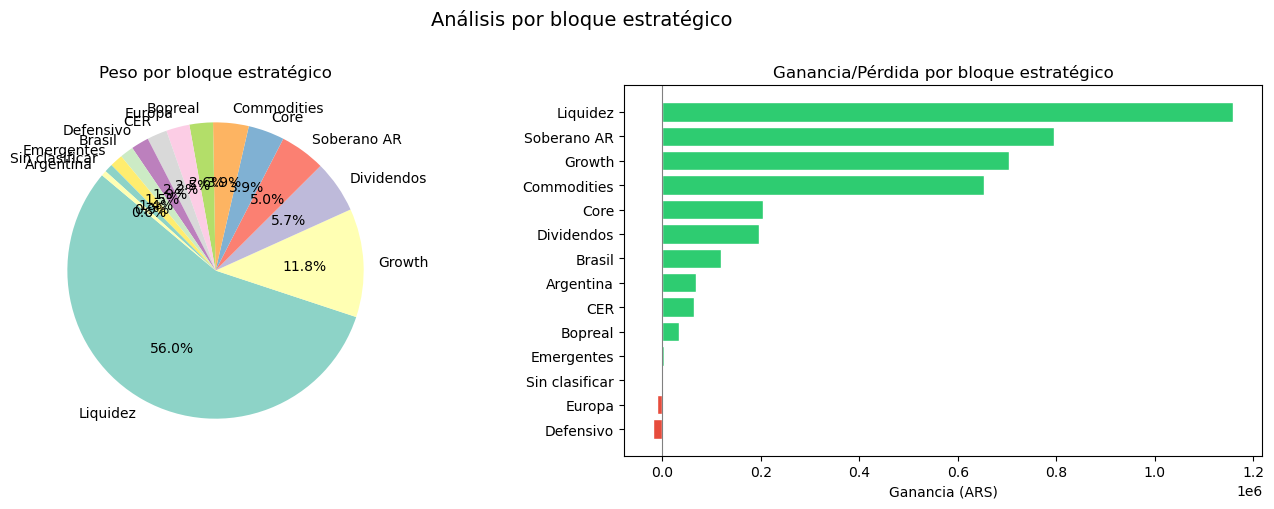

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [10]:
# Celda 10 — Distribución por bloque estratégico

base_bloques = df_total.copy()

# Si querés excluir liquidez, descomentá esta línea:
# base_bloques = base_bloques[base_bloques['Tipo'] != 'Liquidez'].copy()

base_bloques['Bloque'] = base_bloques['Bloque'].fillna('Sin Bloque')

df_bloques = (
    base_bloques.groupby('Bloque', dropna=False)
    .agg(
        Posiciones=('Ticker_IOL', 'count'),
        Valorizado_ARS=('Valorizado_ARS', 'sum'),
        Valor_USD=('Valor_USD', 'sum'),
        Ganancia_ARS=('Ganancia_ARS', 'sum'),
    )
    .assign(Peso_PCT=lambda x: (x['Valorizado_ARS'] / x['Valorizado_ARS'].sum() * 100).round(2))
    .sort_values('Valorizado_ARS', ascending=False)
)

df_bloques_gan = df_bloques.sort_values('Ganancia_ARS', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    df_bloques['Peso_PCT'],
    labels=df_bloques.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Set3.colors[:len(df_bloques)]
)
axes[0].set_title('Peso por bloque estratégico', fontsize=12)

colors_bar = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_bloques_gan['Ganancia_ARS']]
axes[1].barh(df_bloques_gan.index, df_bloques_gan['Ganancia_ARS'], color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Ganancia (ARS)')
axes[1].set_title('Ganancia/Pérdida por bloque estratégico', fontsize=12)

plt.suptitle('Análisis por bloque estratégico', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

display(
    df_bloques.style
    .background_gradient(subset=['Peso_PCT'], cmap='Blues')
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .format({
        'Valorizado_ARS': '${:,.0f}',
        'Valor_USD':      'USD {:,.2f}',
        'Ganancia_ARS':   '${:,.0f}',
        'Peso_PCT':       '{:.2f}%',
    })
    .set_caption('Datos: distribución por bloque estratégico')
)


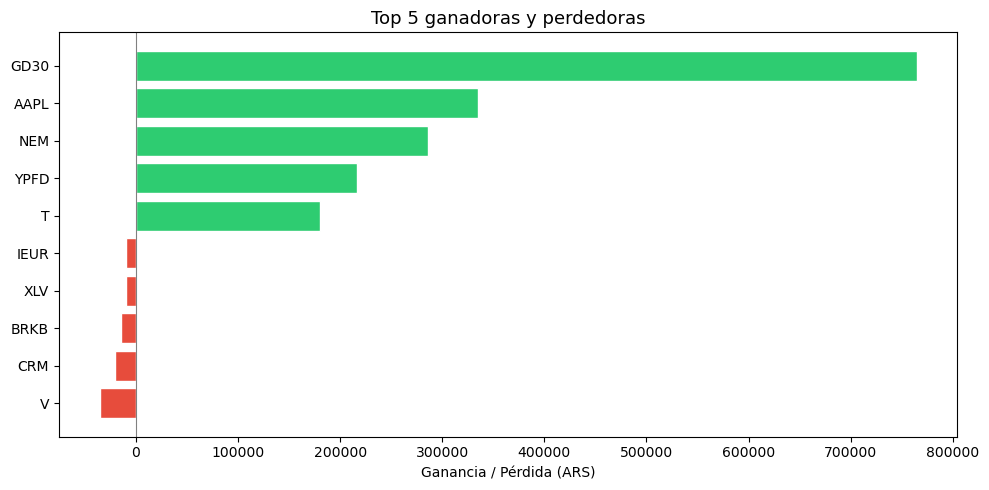


TOP 5 — Posiciones ganadoras


ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).


TOP 5 — Posiciones perdedoras


ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [11]:
# Celda 11 — Top 5 ganadoras y perdedoras

base_top = df_total.copy()

# Recomendado: excluir liquidez para no mezclar cash management con activos de riesgo
base_top = base_top[base_top['Tipo'] != 'Liquidez'].copy()

base_top = base_top[base_top['Ganancia_ARS'].notna()].copy()
base_top = base_top.sort_values('Ganancia_ARS', ascending=False)

top_gan = base_top.head(5).copy()
top_per = base_top.tail(5).copy()

combined = pd.concat([top_gan, top_per], ignore_index=True).sort_values('Ganancia_ARS')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in combined['Ganancia_ARS']]
ax.barh(combined['Ticker_IOL'], combined['Ganancia_ARS'], color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Ganancia / Pérdida (ARS)')
ax.set_title('Top 5 ganadoras y perdedoras', fontsize=13)
plt.tight_layout()
plt.show()

print('\nTOP 5 — Posiciones ganadoras')
display(
    top_gan[['Ticker_IOL', 'Bloque', 'Tipo', 'Ganancia_ARS', 'Peso_%', 'Valor_USD']].style
    .background_gradient(subset=['Ganancia_ARS'], cmap='Greens')
    .format({
        'Ganancia_ARS': '${:,.0f}',
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
    })
    .set_caption('Datos: top 5 ganadoras')
)

print('\nTOP 5 — Posiciones perdedoras')
display(
    top_per[['Ticker_IOL', 'Bloque', 'Tipo', 'Ganancia_ARS', 'Peso_%', 'Valor_USD']].style
    .background_gradient(subset=['Ganancia_ARS'], cmap='Reds_r')
    .format({
        'Ganancia_ARS': '${:,.0f}',
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
    })
    .set_caption('Datos: top 5 perdedoras')
)


In [12]:
# Celda 12 — Consenso de analistas por posición

if not df_ratings_res.empty:
    df_rat_display = df[['Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Valor_USD']].copy()
    df_rat_display = df_rat_display.merge(
        df_ratings_res.reset_index(),
        on='Ticker_Finviz',
        how='left'
    )
    df_rat_display = df_rat_display.sort_values('Valor_USD', ascending=False)

    display(
        df_rat_display[
            ['Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Valor_USD', 'total_ratings', 'consenso', 'consenso_n']
        ]
        .rename(columns={
            'Ticker_IOL': 'Ticker IOL',
            'Ticker_Finviz': 'Ticker Finviz',
            'Valor_USD': 'Valor USD',
            'total_ratings': 'Total Ratings',
            'consenso': 'Consenso',
            'consenso_n': 'Ratings del consenso',
        })
        .style
        .format({'Valor USD': 'USD {:,.2f}'}, na_rep='—')
        .set_caption('Consenso de analistas por posición')
    )
else:
    print('⚠️ No se obtuvieron ratings')


,Ticker IOL,Ticker Finviz,Bloque,Valor USD,Total Ratings,Consenso,Ratings del consenso
18,SPY,SPY,Core,USD 849.89,—,—,—
0,AAPL,AAPL,Growth,USD 847.35,20,Reiterated,17
19,T,T,Dividendos,USD 827.90,20,Upgrade,8
14,MELI,MELI,Growth,USD 669.84,20,Upgrade,7
11,IEUR,IEUR,Europa,USD 579.21,—,—,—
2,AMZN,AMZN,Growth,USD 532.21,20,Reiterated,17
16,NEM,NEM,Commodities,USD 393.92,20,Upgrade,9
12,KO,KO,Dividendos,USD 379.33,20,Reiterated,10
9,EWZ,EWZ,Brasil,USD 339.22,—,—,—
8,EEM,EEM,Emergentes,USD 321.33,—,—,—


In [13]:
# Celda 13 — Alertas automáticas (corregida)

alertas = []

umbral_mep_alto = mep_real * (1 + ALERTA_MEP_DESVIO_PCT / 100)
umbral_mep_bajo = mep_real * (1 - ALERTA_MEP_DESVIO_PCT / 100)
UMBRAL_CONCENTRACION_PESO = 4.0

# Mapa de peso real sobre portfolio total
peso_total_map = df_total.set_index("Ticker_IOL")["Peso_%"].to_dict()

# ── CEDEARs: MEP, pérdida, beta, concentración real ──────────────────────────
for _, row in df.iterrows():
    ticker = row['Ticker_IOL']
    peso_real = peso_total_map.get(ticker)

    if pd.notna(row['Ganancia_ARS']) and row['Ganancia_ARS'] < ALERTA_PERDIDA_MINIMA:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Pérdida significativa',
            'Detalle': f"Ganancia: ${row['Ganancia_ARS']:,.0f} ARS"
        })

    if pd.notna(row['MEP_Implicito']) and row['MEP_Implicito'] > umbral_mep_alto:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'MEP implícito alto',
            'Detalle': f"MEP implícito: ${row['MEP_Implicito']:,.0f} | MEP real: ${mep_real:,.0f}"
        })

    if pd.notna(row['MEP_Implicito']) and row['MEP_Implicito'] < umbral_mep_bajo:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'MEP implícito bajo',
            'Detalle': f"MEP implícito: ${row['MEP_Implicito']:,.0f} | MEP real: ${mep_real:,.0f}"
        })

    if pd.notna(row.get('Beta')) and row['Beta'] >= 1.5 and pd.notna(peso_real) and peso_real >= 2:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Alta beta con peso relevante',
            'Detalle': f"Beta: {row['Beta']:.2f} | Peso total: {peso_real:.2f}%"
        })

    if pd.notna(peso_real) and peso_real >= UMBRAL_CONCENTRACION_PESO:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Concentración elevada',
            'Detalle': f"Peso en cartera total: {peso_real:.2f}%"
        })

# ── Acciones locales ──────────────────────────────────────────────────────────
for _, row in df_local.iterrows():
    ticker = row['Ticker_IOL']
    peso_real = peso_total_map.get(ticker)

    if pd.notna(row['Ganancia_ARS']) and row['Ganancia_ARS'] < ALERTA_PERDIDA_MINIMA:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Pérdida significativa (acción local)',
            'Detalle': f"Ganancia: ${row['Ganancia_ARS']:,.0f} ARS"
        })

    if pd.notna(peso_real) and peso_real >= UMBRAL_CONCENTRACION_PESO:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Concentración elevada (acción local)',
            'Detalle': f"Peso en cartera total: {peso_real:.2f}%"
        })

# ── Bonos ─────────────────────────────────────────────────────────────────────
for _, row in df_bonos.iterrows():
    ticker = row['Ticker_IOL']
    peso_real = peso_total_map.get(ticker)

    if pd.notna(row['Ganancia_ARS']) and row['Ganancia_ARS'] < ALERTA_PERDIDA_MINIMA:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Pérdida significativa (bono)',
            'Detalle': f"Ganancia: ${row['Ganancia_ARS']:,.0f} ARS"
        })

    if pd.notna(peso_real) and peso_real >= UMBRAL_CONCENTRACION_PESO:
        alertas.append({
            'Ticker': ticker,
            'Tipo': 'Concentración elevada (bono)',
            'Detalle': f"Peso en cartera total: {peso_real:.2f}%"
        })

df_alertas = pd.DataFrame(alertas)

print(f'ALERTAS AUTOMÁTICAS ({len(alertas)} detectadas)')
print('─' * 60)

if not df_alertas.empty:
    display(
        df_alertas.style
        .hide(axis='index')
        .set_caption('Alertas del portafolio')
    )
else:
    print('✅ Sin alertas con los umbrales configurados')

print(f'\nMEP real usado:              ${mep_real:,.2f} ARS/USD')
print(f'Desvío MEP para alerta:      ±{ALERTA_MEP_DESVIO_PCT}%')
print(f'Pérdida mínima absoluta:     ${ALERTA_PERDIDA_MINIMA:,.0f} ARS')
print(f'Umbral concentración:        {UMBRAL_CONCENTRACION_PESO:.2f}%')
print('\nNota: Beta y MEP implícito aplican solo a CEDEARs con datos Finviz.')


ALERTAS AUTOMÁTICAS (3 detectadas)
────────────────────────────────────────────────────────────


Ticker,Tipo,Detalle
BRKB,Pérdida significativa,"Ganancia: $-14,560 ARS"
CRM,Pérdida significativa,"Ganancia: $-20,789 ARS"
V,Pérdida significativa,"Ganancia: $-35,440 ARS"



MEP real usado:              $1,434.30 ARS/USD
Desvío MEP para alerta:      ±5%
Pérdida mínima absoluta:     $-10,000 ARS
Umbral concentración:        4.00%

Nota: Beta y MEP implícito aplican solo a CEDEARs con datos Finviz.


---
## 💼 Módulo 5 — Portafolio IOL detallado

Tabla completa con MEP implícito real, valor en USD por posición y gráficos de distribución.

In [14]:
# Celda 14 — Tablas resumen por familia

# ── 0. Agregar peso real sobre portfolio total ────────────────────────────────
peso_total_map = df_total.set_index("Ticker_IOL")["Peso_%"].to_dict()

df = df.copy()
df_local = df_local.copy()
df_bonos = df_bonos.copy()
df_liquidez = df_liquidez.copy()

df["Peso_Portafolio_%"] = df["Ticker_IOL"].map(peso_total_map)
df_local["Peso_Portafolio_%"] = df_local["Ticker_IOL"].map(peso_total_map)
df_bonos["Peso_Portafolio_%"] = df_bonos["Ticker_IOL"].map(peso_total_map)
df_liquidez["Peso_Portafolio_%"] = df_liquidez["Ticker_IOL"].map(peso_total_map)

# ── Tabla resumen — CEDEARs ───────────────────────────────────────────────────
cols_cedears = [
    'Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Cantidad', 'Ratio', 'Acciones_Eq',
    'PPC_ARS', 'Precio_ARS', 'Precio_USD_CEDEAR', 'MEP_Implicito',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df[cols_cedears].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Acciones_Eq':         '{:.4f}',
        'PPC_ARS':             '${:,.0f}',
        'Precio_ARS':          '${:,.0f}',
        'Precio_USD_CEDEAR':   'USD {:.2f}',
        'MEP_Implicito':       '${:,.1f}',
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('CEDEARs — valor estimado en USD por posición')
)

# ── Tabla resumen — Acciones locales ─────────────────────────────────────────
cols_locales = [
    'Ticker_IOL', 'Bloque', 'Cantidad',
    'Precio_ARS', 'PPC_ARS', 'MEP_Usado',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df_local[cols_locales].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Precio_ARS':          '${:,.0f}',
        'PPC_ARS':             '${:,.0f}',
        'MEP_Usado':           '${:,.2f}',
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('Acciones locales — valor estimado en USD vía MEP real')
)

# ── Tabla resumen — Bonos ─────────────────────────────────────────────────────
cols_bonos = [
    'Ticker_IOL', 'Bloque', 'Cantidad', 'Cantidad_Real', 'VN_Factor',
    'Precio_ARS', 'PPC_ARS', 'MEP_Usado',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df_bonos[cols_bonos].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Cantidad':            '{:,.0f}',
        'Cantidad_Real':       '{:.2f}',
        'VN_Factor':           '{:,.0f}',
        'Precio_ARS':          '${:,.2f}',
        'PPC_ARS':             '${:,.2f}',
        'MEP_Usado':           '${:,.2f}',
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('Bonos — valor estimado en USD vía MEP real, normalizando por VN_Factor')
)

# ── Tabla resumen — Liquidez ──────────────────────────────────────────────────
cols_liquidez = [
    'Ticker_IOL', 'Descripcion', 'Bloque', 'Moneda',
    'Valorizado_ARS', 'Valor_USD', 'Ganancia_ARS', 'Peso_Portafolio_%'
]

display(
    df_liquidez[cols_liquidez].set_index('Ticker_IOL')
    .sort_values('Valor_USD', ascending=False)
    .style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .background_gradient(subset=['Peso_Portafolio_%'], cmap='Blues')
    .format({
        'Valorizado_ARS':      '${:,.0f}',
        'Valor_USD':           'USD {:,.2f}',
        'Ganancia_ARS':        '${:,.0f}',
        'Peso_Portafolio_%':   '{:.2f}%',
    }, na_rep='—')
    .set_caption('Liquidez — caución y FCIs')
)


ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

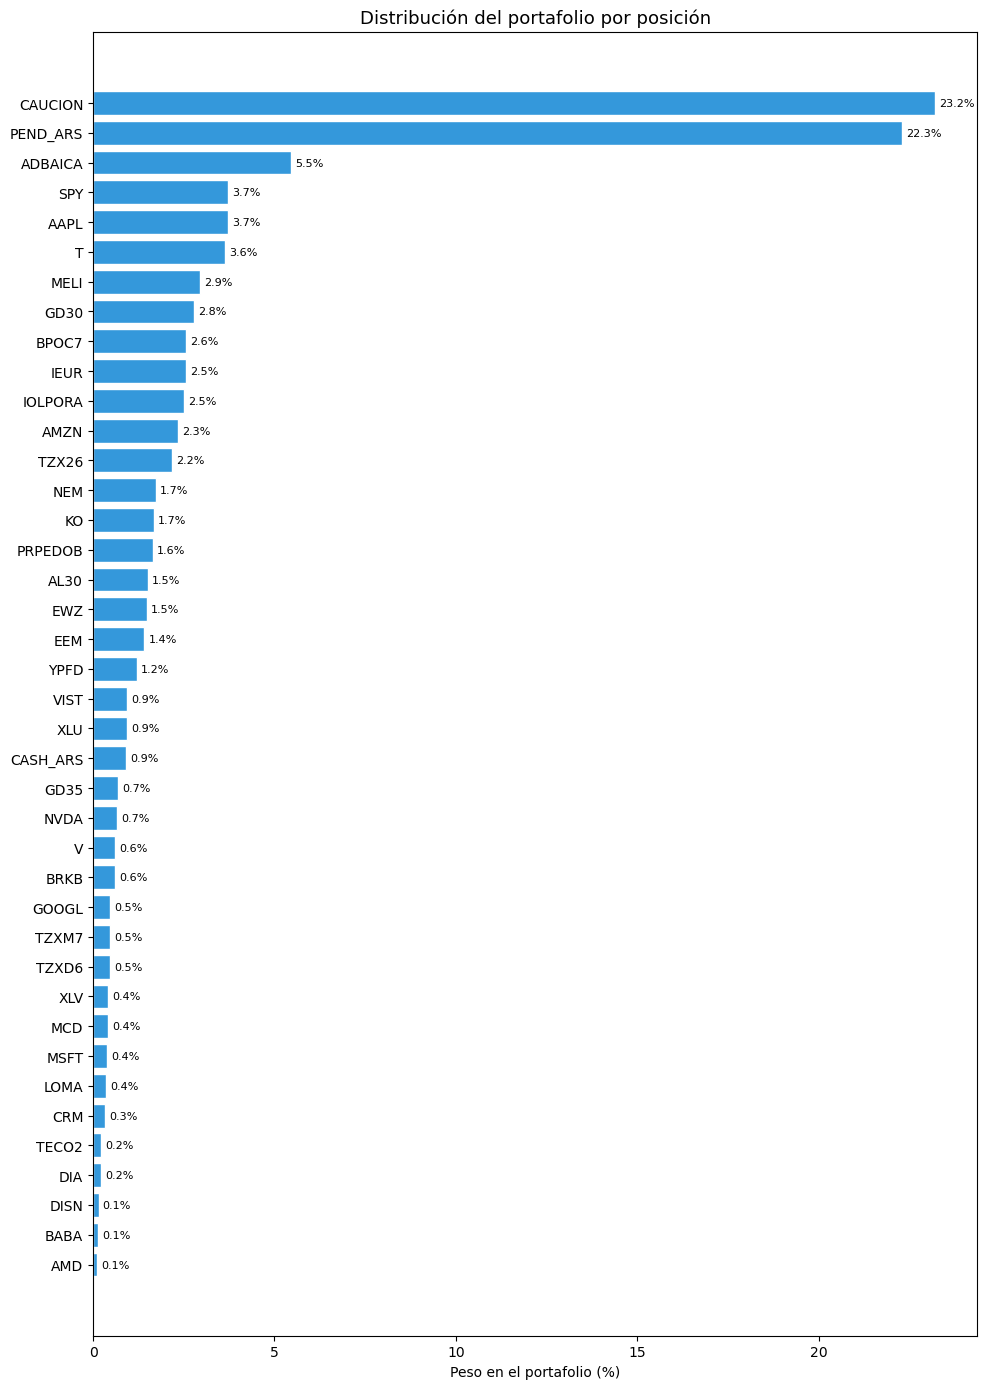

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [15]:
# Celda 15 — Gráfico peso % por posición

df_peso = (
    df_total[['Ticker_IOL', 'Peso_%', 'Bloque', 'Tipo']]
    .copy()
    .sort_values('Peso_%', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_peso) * 0.35)))
bars = ax.barh(df_peso['Ticker_IOL'], df_peso['Peso_%'], color='#3498db', edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
ax.set_xlabel('Peso en el portafolio (%)')
ax.set_title('Distribución del portafolio por posición', fontsize=13)
plt.tight_layout()
plt.show()

display(
    df_peso.style
    .background_gradient(subset=['Peso_%'], cmap='Blues')
    .format({'Peso_%': '{:.2f}%'})
    .set_caption('Datos: peso % por posición')
)


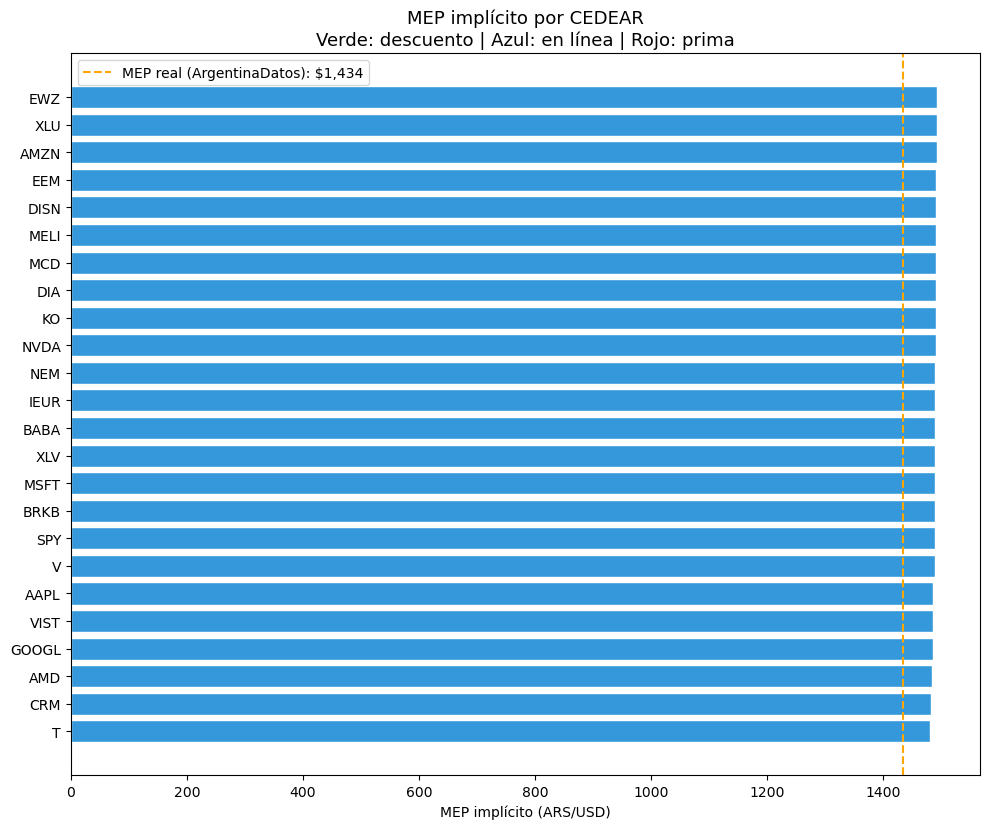

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [16]:
# Celda 16 — MEP implícito por ticker

umbral_superior = mep_real * (1 + ALERTA_MEP_DESVIO_PCT / 100)
umbral_inferior = mep_real * (1 - ALERTA_MEP_DESVIO_PCT / 100)

df_mep = (
    df[['Ticker_IOL', 'MEP_Implicito']]
    .dropna()
    .sort_values('MEP_Implicito')
    .copy()
)

colors = [
    '#e74c3c' if v > umbral_superior else
    '#2ecc71' if v < umbral_inferior else
    '#3498db'
    for v in df_mep['MEP_Implicito']
]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_mep) * 0.35)))
ax.barh(df_mep['Ticker_IOL'], df_mep['MEP_Implicito'], color=colors, edgecolor='white')
ax.axvline(
    mep_real,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    label=f'MEP real (ArgentinaDatos): ${mep_real:,.0f}'
)
ax.set_xlabel('MEP implícito (ARS/USD)')
ax.set_title('MEP implícito por CEDEAR\nVerde: descuento | Azul: en línea | Rojo: prima', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

df_mep_tabla = df_mep.copy()
df_mep_tabla['vs_MEP_real'] = df_mep_tabla['MEP_Implicito'] - mep_real
df_mep_tabla['Desvio_%'] = ((df_mep_tabla['MEP_Implicito'] - mep_real) / mep_real * 100).round(2)
df_mep_tabla['Señal'] = df_mep_tabla['Desvio_%'].apply(
    lambda x: 'Prima' if x > ALERTA_MEP_DESVIO_PCT else (
        'Descuento' if x < -ALERTA_MEP_DESVIO_PCT else 'En línea'
    )
)

display(
    df_mep_tabla.style
    .background_gradient(subset=['Desvio_%'], cmap='RdYlGn_r')
    .format({
        'MEP_Implicito': '${:,.1f}',
        'vs_MEP_real': '${:,.1f}',
        'Desvio_%': '{:.2f}%',
    })
    .set_caption(f'Datos: MEP implícito vs MEP real (${mep_real:,.0f})')
)


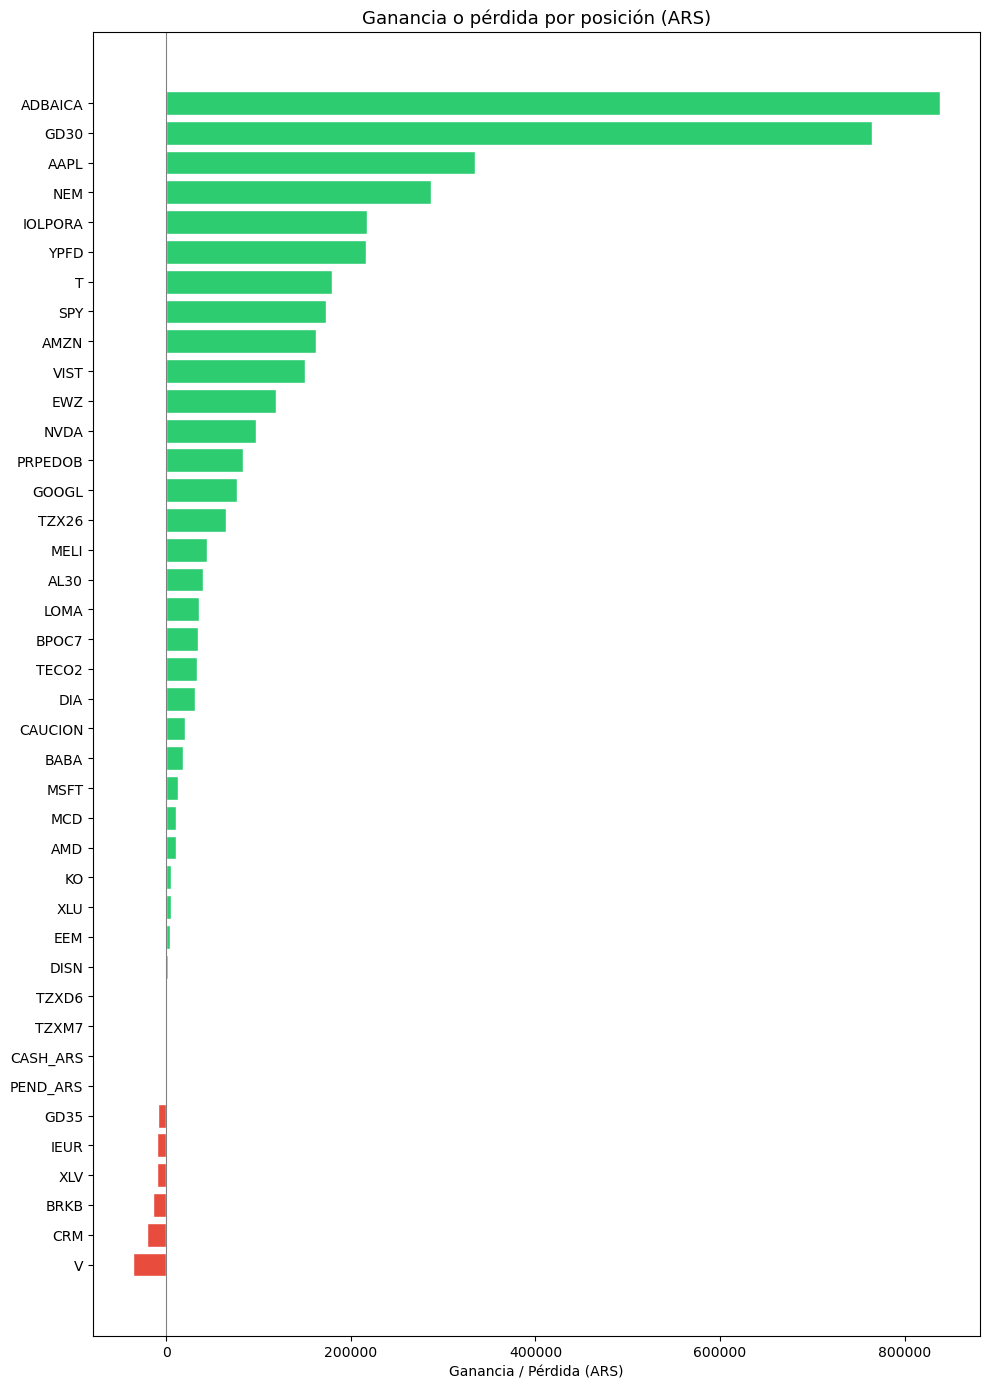

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [17]:
# Celda 17 — Ganancia/Pérdida en ARS por posición

base_gan = df_total.copy()

# Si querés excluir liquidez, descomentá:
# base_gan = base_gan[base_gan['Tipo'] != 'Liquidez'].copy()

df_gan = base_gan[['Ticker_IOL', 'Ganancia_ARS', 'Bloque', 'Tipo']].copy()
df_gan = df_gan[df_gan['Ganancia_ARS'].notna()].sort_values('Ganancia_ARS')

colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in df_gan['Ganancia_ARS']]

fig, ax = plt.subplots(figsize=(10, max(6, len(df_gan) * 0.35)))
ax.barh(df_gan['Ticker_IOL'], df_gan['Ganancia_ARS'], color=colors, edgecolor='white')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Ganancia / Pérdida (ARS)')
ax.set_title('Ganancia o pérdida por posición (ARS)', fontsize=13)
plt.tight_layout()
plt.show()

display(
    df_gan.style
    .background_gradient(subset=['Ganancia_ARS'], cmap='RdYlGn')
    .format({'Ganancia_ARS': '${:,.0f}'})
    .set_caption('Datos: ganancia/pérdida por posición (ARS)')
)


---
## 📋 Módulo 6 — Fundamentals

Tabla comparativa de métricas del subyacente (Finviz): P/E, EPS, Beta, performance.

In [18]:
# Celda 18 — Tabla comparativa fundamentals Finviz

cols_fund = [
    'Company', 'Sector', 'P/E', 'Fwd P/E', 'EPS (ttm)',
    'Dividend', 'Beta', 'Perf Week', 'Perf Month', 'Perf YTD'
]
cols_fund = [c for c in cols_fund if c in df.columns]

cols_base = ['Ticker_IOL', 'Ticker_Finviz', 'Bloque', 'Valor_USD', 'Peso_%']
cols_tabla = cols_base + cols_fund

df_fund_display = df[cols_tabla].copy().sort_values('Valor_USD', ascending=False)

display(
    df_fund_display.style
    .background_gradient(subset=[c for c in ['Perf Week', 'Perf Month', 'Perf YTD'] if c in df_fund_display.columns], cmap='RdYlGn')
    .format({
        'Valor_USD': 'USD {:,.2f}',
        'Peso_%': '{:.2f}%',
        'P/E': '{:.1f}',
        'Fwd P/E': '{:.1f}',
        'EPS (ttm)': '{:.2f}',
        'Dividend': '{:.2f}%',
        'Beta': '{:.2f}',
        'Perf Week': '{:.2f}%',
        'Perf Month': '{:.2f}%',
        'Perf YTD': '{:.2f}%',
    }, na_rep='—')
    .set_caption('Fundamentals del subyacente (Finviz)')
)


ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

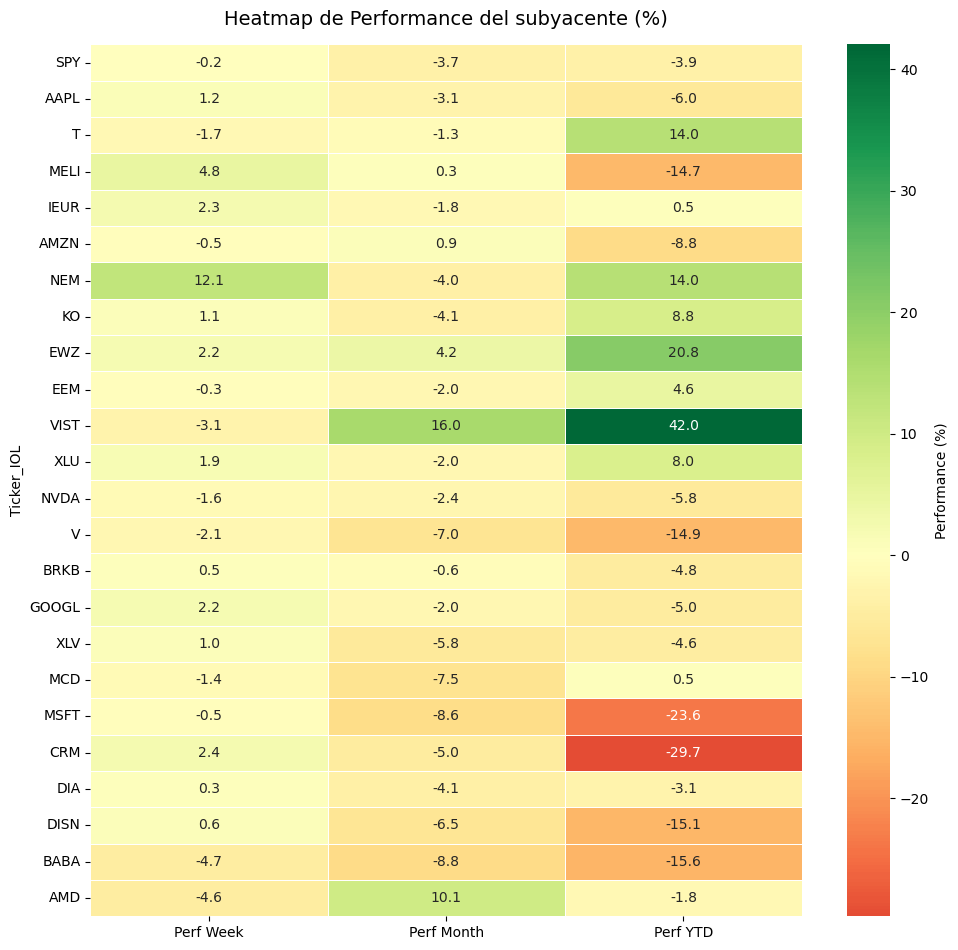

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [19]:
# Celda 19 — Heatmap performance del subyacente

perf_cols = [c for c in ['Perf Week', 'Perf Month', 'Perf YTD'] if c in df.columns]

df_perf = (
    df[['Ticker_IOL', 'Valor_USD', 'Peso_%'] + perf_cols]
    .copy()
    .sort_values('Valor_USD', ascending=False)
    .set_index('Ticker_IOL')[perf_cols]
    .dropna(how='all')
)

fig, ax = plt.subplots(figsize=(10, max(6, len(df_perf) * 0.4)))
sns.heatmap(
    df_perf,
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    cmap='RdYlGn',
    center=0,
    cbar_kws={'label': 'Performance (%)'},
    ax=ax
)
ax.set_title('Heatmap de Performance del subyacente (%)', fontsize=14, pad=14)
plt.tight_layout()
plt.show()

display(
    df_perf.style
    .background_gradient(subset=perf_cols, cmap='RdYlGn')
    .format({c: '{:.2f}%' for c in perf_cols}, na_rep='—')
    .set_caption('Datos: performance del subyacente (%)')
)


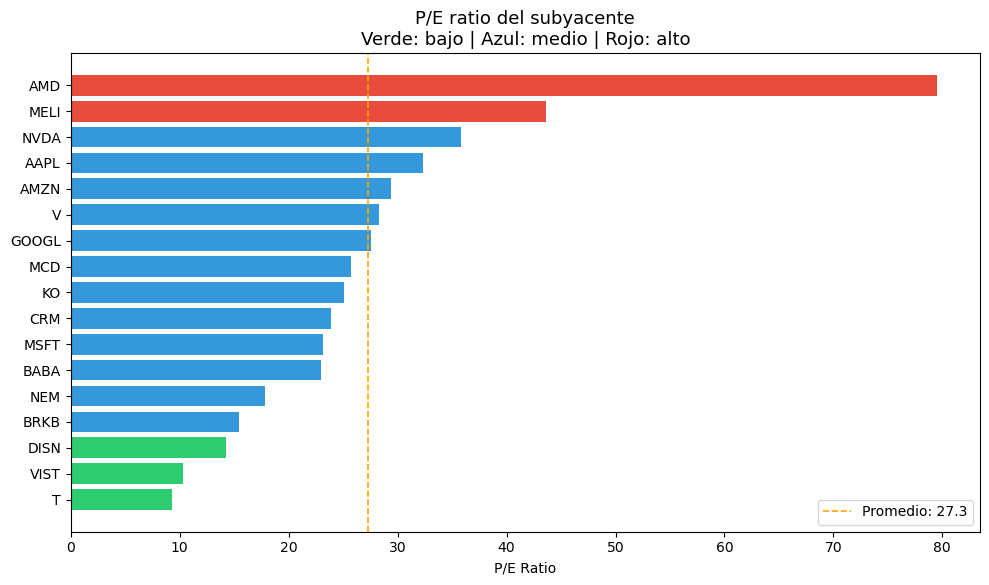

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [20]:
# Celda 20 — P/E ratio del subyacente

if 'P/E' in df.columns:
    base_pe = df.copy()

    # Opcional: excluir ETFs para una lectura más homogénea
    # base_pe = base_pe[base_pe['Tipo_Patrimonial'] != 'ETF'].copy() if 'Tipo_Patrimonial' in base_pe.columns else base_pe

    df_pe = (
        base_pe[['Ticker_IOL', 'P/E', 'Valor_USD', 'Bloque']]
        .dropna(subset=['P/E'])
        .sort_values('P/E')
        .copy()
    )

    promedio_pe = df_pe['P/E'].mean()

    colors = [
        '#e74c3c' if v > 40 else '#2ecc71' if v < 15 else '#3498db'
        for v in df_pe['P/E']
    ]

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_pe) * 0.35)))
    ax.barh(df_pe['Ticker_IOL'], df_pe['P/E'], color=colors)
    ax.axvline(promedio_pe, color='orange', linestyle='--', linewidth=1.2, label=f'Promedio: {promedio_pe:.1f}')
    ax.set_xlabel('P/E Ratio')
    ax.set_title('P/E ratio del subyacente\nVerde: bajo | Azul: medio | Rojo: alto', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

    df_pe_tabla = df_pe[['Ticker_IOL', 'Bloque', 'Valor_USD', 'P/E']].copy()
    df_pe_tabla['vs_promedio'] = (df_pe_tabla['P/E'] - promedio_pe).round(2)
    df_pe_tabla['Señal'] = df_pe_tabla['P/E'].apply(
        lambda x: 'P/E alto' if x > 40 else ('P/E bajo' if x < 15 else 'P/E medio')
    )

    display(
        df_pe_tabla.style
        .background_gradient(subset=['P/E'], cmap='RdYlGn_r')
        .format({
            'Valor_USD': 'USD {:,.2f}',
            'P/E': '{:.1f}',
            'vs_promedio': '{:+.1f}',
        })
        .set_caption(f'Datos: P/E ratio (promedio simple: {promedio_pe:.1f})')
    )


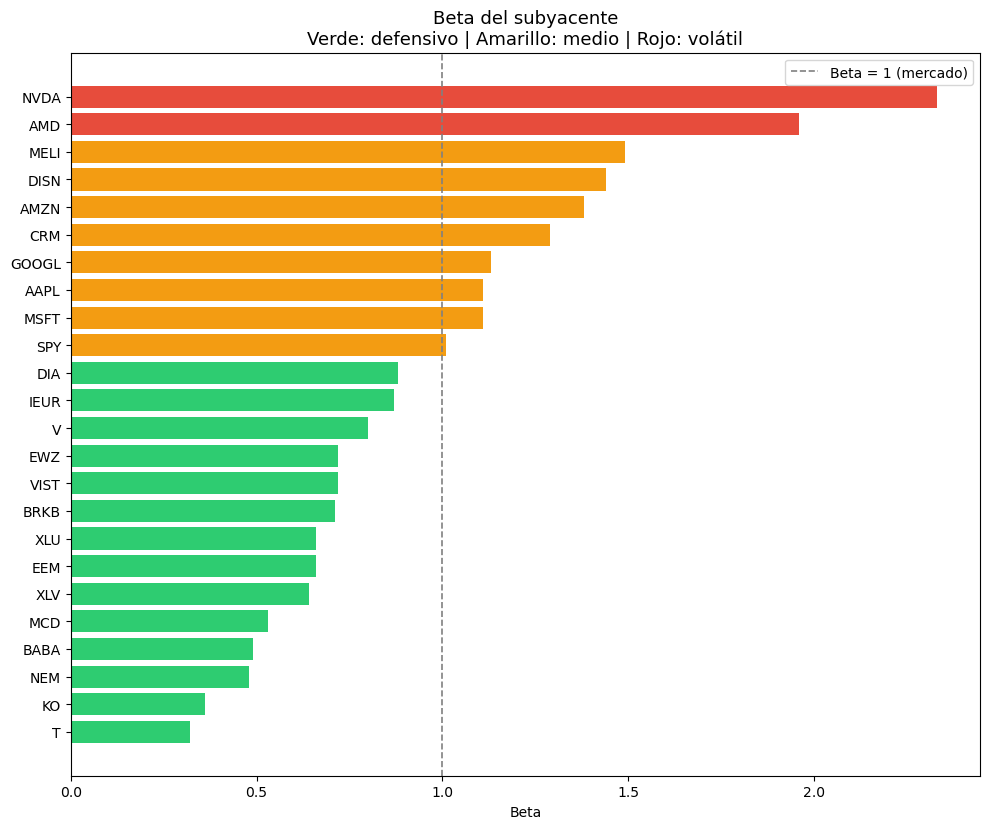

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

In [21]:
# Celda 21 — Beta

if 'Beta' in df.columns:
    df_beta = (
        df[['Ticker_IOL', 'Beta', 'Valor_USD', 'Peso_%', 'Bloque']]
        .dropna(subset=['Beta'])
        .sort_values('Beta')
        .copy()
    )

    colors = ['#e74c3c' if v > 1.5 else '#f39c12' if v > 1 else '#2ecc71' for v in df_beta['Beta']]

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_beta) * 0.35)))
    ax.barh(df_beta['Ticker_IOL'], df_beta['Beta'], color=colors)
    ax.axvline(1, color='gray', linestyle='--', linewidth=1.2, label='Beta = 1 (mercado)')
    ax.set_xlabel('Beta')
    ax.set_title('Beta del subyacente\nVerde: defensivo | Amarillo: medio | Rojo: volátil', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

    df_beta_tabla = df_beta.copy()
    df_beta_tabla['Señal'] = df_beta_tabla['Beta'].apply(
        lambda x: 'Alta volatilidad' if x > 1.5 else ('Moderado' if x > 1 else 'Defensivo')
    )

    display(
        df_beta_tabla.style
        .background_gradient(subset=['Beta'], cmap='RdYlGn_r')
        .format({
            'Beta': '{:.2f}',
            'Valor_USD': 'USD {:,.2f}',
            'Peso_%': '{:.2f}%',
        })
        .set_caption('Datos: Beta por ticker')
    )


---
## ⭐ Módulo 7 — Ratings de analistas

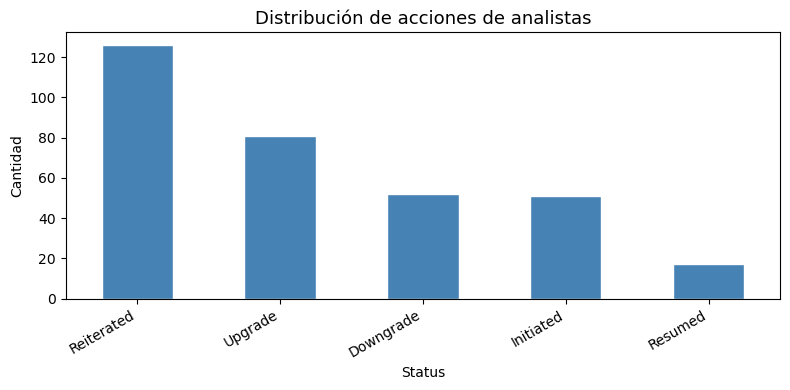

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).


Resumen por ticker:


,Ticker,total,consenso,consenso_n
0,AAPL,20,Reiterated,17
2,AMZN,20,Reiterated,17
13,NVDA,20,Reiterated,17
11,MSFT,20,Reiterated,16
7,GOOGL,20,Reiterated,14
1,AMD,20,Upgrade,10
8,KO,20,Reiterated,10
12,NEM,20,Upgrade,9
3,BABA,20,Upgrade,8
14,T,20,Upgrade,8



Detalle reciente de ratings:


,Ticker,Date,Status,Price
0,AAPL,2026-03-23,Reiterated,$325 → $320
1,AAPL,2026-03-05,Reiterated,$267 → $268
2,AAPL,2026-03-03,Reiterated,$239 → $248
3,AAPL,2026-02-25,Reiterated,$241 → $270
4,AAPL,2026-02-10,Reiterated,$325 → $340
5,AAPL,2026-01-30,Upgrade,$300
6,AAPL,2026-01-30,Reiterated,$250 → $267
7,AAPL,2026-01-30,Reiterated,$300 → $315
8,AAPL,2026-01-30,Reiterated,$315 → $325
9,AAPL,2026-01-30,Reiterated,$230 → $239


In [22]:
# Celda 22 — Ratings de analistas

if not df_ratings.empty:
    action_col = next((c for c in df_ratings.columns if c.lower() in ['action', 'rating', 'status']), None)

    if action_col:
        base_ratings = df_ratings.copy()
        base_ratings = base_ratings[base_ratings[action_col].notna()].copy()

        conteo = base_ratings[action_col].value_counts()

        fig, ax = plt.subplots(figsize=(8, 4))
        conteo.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title('Distribución de acciones de analistas', fontsize=13)
        ax.set_ylabel('Cantidad')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

        display(
            conteo.to_frame(name='Cantidad').style
            .background_gradient(cmap='Blues')
            .set_caption('Datos: distribución de acciones de analistas')
        )

        resumen_por_ticker = (
            base_ratings.groupby('Ticker')[action_col]
            .agg(
                total='count',
                consenso=lambda s: s.value_counts().index[0] if not s.value_counts().empty else None,
                consenso_n=lambda s: int(s.value_counts().iloc[0]) if not s.value_counts().empty else None,
            )
            .reset_index()
            .sort_values(['total', 'consenso_n'], ascending=False)
        )

        print("\nResumen por ticker:")
        display(
            resumen_por_ticker.style
            .format({'total': '{:,.0f}', 'consenso_n': '{:,.0f}'}, na_rep='—')
            .set_caption('Resumen de ratings por ticker')
        )

        detalle_cols = [c for c in ['Ticker', 'Date', 'Publisher', action_col, 'Price Target', 'Price', 'Analyst'] if c in base_ratings.columns]

        print("\nDetalle reciente de ratings:")
        display(base_ratings[detalle_cols].head(40))
    else:
        print('⚠️ No se encontró una columna de acción/rating/status en df_ratings')
else:
    print('⚠️ Sin datos de ratings')


---
## 📰 Módulo 8 — Noticias recientes por ticker

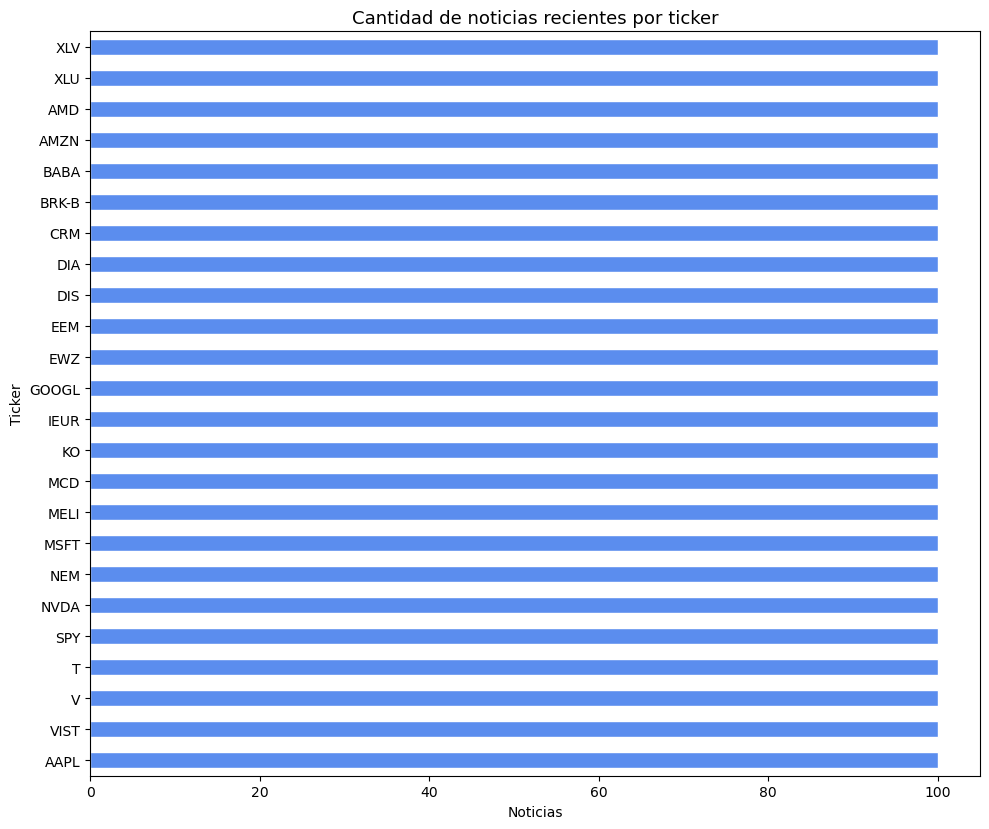

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).

,Ticker,Date,Title,Link
0,AAPL,2026-04-01 19:37:00,Globalstar Rallies on Report That Amazon Is in Buyout Talks,Ver
1,AAPL,2026-04-01 18:48:00,"Amazon eyes $9 billion Globalstar deal to rival SpaceX's Starlink, FT reports",Ver
2,AAPL,2026-04-01 17:56:00,Apple's next chapter: Who succeeds Tim Cook?,Ver
3,AAPL,2026-04-01 17:41:00,"Apple's 50 years of innovation, and how it has remained relevant",Ver
4,AAPL,2026-04-01 17:37:00,"Could Apple's next 50 years of success lie in AI, foldable phones?",Ver
5,AMD,2026-04-01 10:00:00,Nasdaq and Dow continue rally at open as Trump says Iran asks for ceasefire,Ver
6,AMD,2026-04-01 05:14:00,Chinese chipmakers claim nearly half of local market as Nvidia's lead shrinks,Ver
7,AMD,2026-03-31 14:54:00,Chip Stocks Jump as Trump Signals End to Iran War Within Weeks,Ver
8,AMD,2026-03-31 07:00:00,Why OpenAI pulled the plug on AI video platform Sora,Ver
9,AMD,2026-03-31 06:00:00,Trumps Tax Cut Delivers at Least $65 Billion Windfall to Corporations,Ver


In [23]:
# Celda 23 — Noticias recientes

if not df_news.empty:
    base_news = df_news.copy()

    conteo_news = base_news.groupby('Ticker').size().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(5, len(conteo_news) * 0.35)))
    conteo_news.plot(kind='barh', ax=ax, color='#5b8dee', edgecolor='white')
    ax.set_title('Cantidad de noticias recientes por ticker', fontsize=13)
    ax.set_xlabel('Noticias')
    plt.tight_layout()
    plt.show()

    display(
        conteo_news.to_frame(name='Noticias').style
        .background_gradient(cmap='Blues')
        .format({'Noticias': '{:.0f}'})
        .set_caption('Datos: cobertura de noticias por ticker')
    )

    date_col = next((c for c in base_news.columns if 'date' in c.lower() or 'time' in c.lower()), None)
    title_col = next((c for c in base_news.columns if 'title' in c.lower() or 'headline' in c.lower() or 'news' == c.lower()), None)
    link_col = next((c for c in base_news.columns if 'link' in c.lower() or 'url' in c.lower()), None)

    if date_col:
        try:
            base_news = base_news.sort_values(['Ticker', date_col], ascending=[True, False])
        except Exception:
            pass

    df_news_top = base_news.groupby('Ticker').head(5).reset_index(drop=True)

    cols_show = [c for c in ['Ticker', date_col, title_col, link_col] if c]
    if not cols_show:
        cols_show = df_news_top.columns.tolist()[:5]

    if link_col and link_col in cols_show:
        display(
            df_news_top[cols_show].style.format(
                {link_col: lambda url: f'<a href="{url}" target="_blank">Ver</a>' if pd.notna(url) else '—'}
            ).set_caption('Últimas 5 noticias por ticker')
        )
    else:
        display(
            df_news_top[cols_show].style.set_caption('Últimas 5 noticias por ticker')
        )
else:
    print('⚠️ Sin noticias')


---
## 🕵️ Módulo 9 — Operaciones de insiders

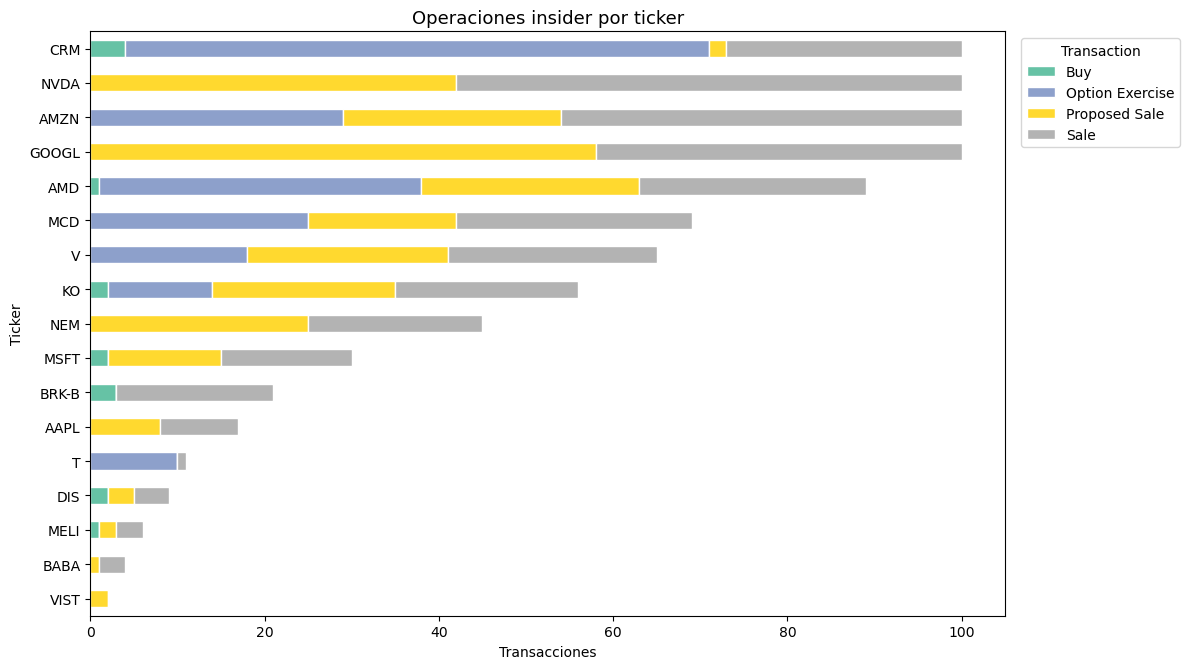

ImportError: Pandas requires version '3.9.3' or newer of 'matplotlib' (version '3.8.0' currently installed).


Detalle reciente de insiders:


,Ticker,Date,Transaction,Relationship
329,CRM,Sep 30 '25,Option Exercise,Chair and CEO
428,GOOGL,Sep 30 '25,Sale,Director
429,GOOGL,Sep 30 '25,Proposed Sale,Director
734,NVDA,Sep 30 '25,Sale,President and CEO
330,CRM,Sep 30 '25,Sale,Chair and CEO
737,NVDA,Sep 30 '25,Proposed Sale,Officer
425,GOOGL,Sep 29 '25,Sale,"President, Global Affairs, CLO"
430,GOOGL,Sep 29 '25,Proposed Sale,Officer
738,NVDA,Sep 29 '25,Sale,President and CEO
741,NVDA,Sep 29 '25,Proposed Sale,Officer


In [24]:
# Celda 24 — Insiders

if not df_insider.empty:
    base_insider = df_insider.copy()

    trans_col = next(
        (c for c in base_insider.columns if c.lower() in ['transaction', 'type', 'option type', 'action']),
        None
    )

    if trans_col:
        base_insider = base_insider[base_insider[trans_col].notna()].copy()

        pivot = base_insider.groupby(['Ticker', trans_col]).size().unstack(fill_value=0)
        pivot['Total'] = pivot.sum(axis=1)
        pivot = pivot.sort_values('Total', ascending=True)
        pivot_plot = pivot.drop(columns=['Total'])

        fig, ax = plt.subplots(figsize=(12, max(5, len(pivot_plot) * 0.4)))
        pivot_plot.plot(kind='barh', ax=ax, stacked=True, colormap='Set2', edgecolor='white')
        ax.set_title('Operaciones insider por ticker', fontsize=13)
        ax.set_xlabel('Transacciones')
        ax.legend(title=trans_col, bbox_to_anchor=(1.01, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

        display(
            pivot.style
            .background_gradient(cmap='Blues')
            .set_caption('Datos: operaciones insider por ticker y tipo')
        )

        date_col = next((c for c in base_insider.columns if 'date' in c.lower() or 'time' in c.lower()), None)
        cols_show = [c for c in ['Ticker', date_col, trans_col, 'Shares', 'Value', 'Owner', 'Relationship'] if c in base_insider.columns]

        detalle = base_insider.copy()
        if date_col:
            try:
                detalle = detalle.sort_values(date_col, ascending=False)
            except Exception:
                pass

        print("\nDetalle reciente de insiders:")
        if cols_show:
            display(detalle[cols_show].head(40))
        else:
            display(detalle.head(40))
    else:
        print('⚠️ No se encontró una columna de tipo de transacción insider')
else:
    print('⚠️ Sin datos insider')


In [25]:
# Celda 25 — checks de integridad

checks = []

checks.append({
    "check": "MEP real disponible",
    "status": "OK" if pd.notna(mep_real) and mep_real > 0 else "ERROR",
    "detalle": f"mep_real={mep_real}"
})

checks.append({
    "check": "df_total no vacío",
    "status": "OK" if not df_total.empty else "ERROR",
    "detalle": f"filas={len(df_total)}"
})

checks.append({
    "check": "Pesos suman ~100%",
    "status": "OK" if abs(df_total["Peso_%"].sum() - 100) <= 0.2 else "WARN",
    "detalle": f"suma={df_total['Peso_%'].sum():.2f}%"
})

checks.append({
    "check": "Bonos valorizados",
    "status": "OK" if df_bonos["Valorizado_ARS"].notna().all() else "WARN",
    "detalle": f"faltantes={df_bonos['Valorizado_ARS'].isna().sum()}"
})

checks.append({
    "check": "CEDEARs con MEP implícito",
    "status": "OK" if df["MEP_Implicito"].notna().all() else "WARN",
    "detalle": f"faltantes={df['MEP_Implicito'].isna().sum()}"
})

checks.append({
    "check": "Finviz con precio USD",
    "status": "OK" if df["Precio_USD_Sub"].notna().all() else "WARN",
    "detalle": f"faltantes={df['Precio_USD_Sub'].isna().sum()}"
})

df_checks = pd.DataFrame(checks)
display(df_checks.style.hide(axis="index").set_caption("Checks de integridad"))


check,status,detalle
MEP real disponible,OK,mep_real=1434.3
df_total no vacío,OK,filas=40
Pesos suman ~100%,OK,suma=100.03%
Bonos valorizados,OK,faltantes=0
CEDEARs con MEP implícito,OK,faltantes=0
Finviz con precio USD,OK,faltantes=0


In [26]:
# Celda 26 — exposición cruzada por tipo y bloque

df_mix = (
    df_total.groupby(["Tipo", "Bloque"], dropna=False)
    .agg(
        posiciones=("Ticker_IOL", "count"),
        valorizado_ars=("Valorizado_ARS", "sum"),
        valor_usd=("Valor_USD", "sum"),
        ganancia_ars=("Ganancia_ARS", "sum"),
    )
    .reset_index()
)

df_mix["peso_%"] = (df_mix["valorizado_ars"] / df_mix["valorizado_ars"].sum() * 100).round(2)
df_mix = df_mix.sort_values(["Tipo", "valorizado_ars"], ascending=[True, False])

display(
    df_mix.style
    .format({
        "valorizado_ars": "${:,.0f}",
        "valor_usd": "USD {:,.2f}",
        "ganancia_ars": "${:,.0f}",
        "peso_%": "{:.2f}%"
    }, na_rep="—")
    .set_caption("Exposición por tipo y bloque")
)


,Tipo,Bloque,posiciones,valorizado_ars,valor_usd,ganancia_ars,peso_%
1,Acción Local,Commodities,1,"$392,700",USD 273.79,"$216,165",1.20%
0,Acción Local,Argentina,2,"$190,068",USD 132.52,"$69,372",0.58%
5,Bono,Soberano AR,3,"$1,620,779","USD 1,130.01","$795,385",4.97%
2,Bono,Bopreal,1,"$834,098",USD 581.54,"$34,666",2.56%
3,Bono,CER,1,"$712,616",USD 496.84,"$65,105",2.18%
4,Bono,Sin clasificar,2,"$298,258",USD 207.95,$380,0.91%
13,CEDEAR,Growth,11,"$3,863,160","USD 2,693.41","$703,876",11.84%
10,CEDEAR,Dividendos,3,"$1,865,090","USD 1,300.35","$196,813",5.71%
8,CEDEAR,Core,2,"$1,288,360",USD 898.25,"$204,956",3.95%
7,CEDEAR,Commodities,2,"$872,980",USD 608.65,"$437,402",2.67%


In [27]:
# Celda 27 — dashboard final condensado

top_peso = df_total.sort_values("Peso_%", ascending=False)[["Ticker_IOL", "Tipo", "Bloque", "Peso_%"]].head(10)
top_gan = df_total.sort_values("Ganancia_ARS", ascending=False)[["Ticker_IOL", "Tipo", "Ganancia_ARS"]].head(5)
top_per = df_total.sort_values("Ganancia_ARS", ascending=True)[["Ticker_IOL", "Tipo", "Ganancia_ARS"]].head(5)

print("=" * 60)
print("DASHBOARD FINAL")
print("=" * 60)
print(f"Total ARS:   ${df_total['Valorizado_ARS'].sum():,.0f}")
print(f"Total USD:   USD {df_total['Valor_USD'].sum():,.2f}")
print(f"Ganancia:    ${df_total['Ganancia_ARS'].sum():,.0f}")
print(f"MEP real:    ${mep_real:,.2f}")
print("=" * 60)

print("\nTop 10 por peso")
display(top_peso.style.format({"Peso_%": "{:.2f}%"}))

print("\nTop 5 ganadoras")
display(top_gan.style.format({"Ganancia_ARS": "${:,.0f}"}))

print("\nTop 5 perdedoras")
display(top_per.style.format({"Ganancia_ARS": "${:,.0f}"}))


DASHBOARD FINAL
Total ARS:   $32,638,579
Total USD:   USD 22,755.76
Ganancia:    $3,977,780
MEP real:    $1,434.30

Top 10 por peso


,Ticker_IOL,Tipo,Bloque,Peso_%
35,CAUCION,Liquidez,Liquidez,23.21%
39,PEND_ARS,Liquidez,Liquidez,22.29%
34,ADBAICA,Liquidez,Liquidez,5.46%
18,SPY,CEDEAR,Core,3.73%
0,AAPL,CEDEAR,Growth,3.72%
19,T,CEDEAR,Dividendos,3.64%
14,MELI,CEDEAR,Growth,2.94%
29,GD30,Bono,Soberano AR,2.78%
28,BPOC7,Bono,Bopreal,2.56%
11,IEUR,CEDEAR,Europa,2.55%



Top 5 ganadoras


,Ticker_IOL,Tipo,Ganancia_ARS
34,ADBAICA,Liquidez,"$837,802"
29,GD30,Bono,"$764,588"
0,AAPL,CEDEAR,"$334,988"
16,NEM,CEDEAR,"$286,472"
36,IOLPORA,Liquidez,"$217,809"



Top 5 perdedoras


,Ticker_IOL,Tipo,Ganancia_ARS
20,V,CEDEAR,"$-35,440"
5,CRM,CEDEAR,"$-20,789"
4,BRKB,CEDEAR,"$-14,560"
23,XLV,CEDEAR,"$-9,990"
11,IEUR,CEDEAR,"$-9,855"


In [28]:
# Celda 28 — score_refuerzo y score_reduccion (corregida)

import numpy as np
import pandas as pd

def rank_score(series, higher_is_better=True, neutral=0.5):
    s = pd.to_numeric(series, errors='coerce')
    out = pd.Series(neutral, index=s.index, dtype=float)
    valid = s.notna()
    if valid.any():
        ranks = s[valid].rank(pct=True, method='average')
        out.loc[valid] = ranks if higher_is_better else (1 - ranks)
    return out

def consensus_to_score(text):
    if pd.isna(text):
        return 0.5
    t = str(text).strip().lower()

    positivos = ['buy', 'outperform', 'overweight', 'upgrade', 'positive', 'strong buy', 'initiated']
    negativos = ['sell', 'underperform', 'underweight', 'downgrade', 'negative', 'reduce']
    neutros = ['hold', 'neutral', 'equal-weight', 'equal weight', 'market perform', 'sector perform', 'reiterated']

    if any(x in t for x in positivos):
        return 1.0
    if any(x in t for x in negativos):
        return 0.0
    if any(x in t for x in neutros):
        return 0.5
    return 0.5

# ── 1. Base unificada ─────────────────────────────────────────────────────────
decision_cols = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valorizado_ARS',
    'Valor_USD', 'Ganancia_ARS', 'Cantidad_Real', 'PPC_ARS'
]
base = df_total[decision_cols].copy()

base['Costo_ARS'] = base['Cantidad_Real'].fillna(0) * base['PPC_ARS'].fillna(0)
base['Ganancia_%'] = np.where(
    base['Costo_ARS'] > 0,
    base['Ganancia_ARS'] / base['Costo_ARS'] * 100,
    np.nan
)

ced_cols = [
    'Ticker_IOL', 'Ticker_Finviz', 'Perf Week', 'Perf Month', 'Perf YTD',
    'Beta', 'P/E', 'MEP_Implicito'
]
ced_data = df[ced_cols].copy()

if not df_ratings_res.empty:
    ratings_map = df_ratings_res.reset_index()[['Ticker_Finviz', 'consenso', 'consenso_n', 'total_ratings']].copy()
    ced_data = ced_data.merge(ratings_map, on='Ticker_Finviz', how='left')
else:
    ced_data['consenso'] = None
    ced_data['consenso_n'] = np.nan
    ced_data['total_ratings'] = np.nan

decision = base.merge(ced_data, on='Ticker_IOL', how='left')
decision = build_decision_base(df_total, df, df_ratings_res, mep_real=mep_real)

decision['Cobertura_Modelo'] = np.where(decision['Ticker_Finviz'].notna(), 'Completa', 'Parcial')
decision['Es_Liquidez'] = decision['Tipo'].eq('Liquidez')
decision['Es_Cedear'] = decision['Tipo'].eq('CEDEAR')
decision['Es_Bono'] = decision['Tipo'].eq('Bono')
decision['Es_Accion_Local'] = decision['Tipo'].eq('Acción Local')
decision['Es_Core'] = decision['Bloque'].eq('Core')

decision['MEP_Premium_%'] = np.where(
    decision['MEP_Implicito'].notna(),
    (decision['MEP_Implicito'] / mep_real - 1) * 100,
    np.nan
)

decision['Consensus_Score'] = decision['consenso'].apply(consensus_to_score)
decision['Consensus_Strength'] = np.where(
    decision['total_ratings'].fillna(0) > 0,
    decision['consenso_n'].fillna(0) / decision['total_ratings'].fillna(1),
    np.nan
)
decision['Consensus_Final'] = (
    0.7 * decision['Consensus_Score'].fillna(0.5) +
    0.3 * decision['Consensus_Strength'].fillna(0.5)
)

# Ganancia normalizada para evitar outliers absurdos en bonos
decision['Ganancia_%_Cap'] = decision['Ganancia_%'].clip(lower=-100, upper=150)

# ── 2. Scores parciales ───────────────────────────────────────────────────────
decision['s_low_weight'] = rank_score(decision['Peso_%'], higher_is_better=False)
decision['s_high_weight'] = rank_score(decision['Peso_%'], higher_is_better=True)

decision['s_mom_week'] = rank_score(decision['Perf Week'], higher_is_better=True)
decision['s_mom_month'] = rank_score(decision['Perf Month'], higher_is_better=True)
decision['s_mom_ytd'] = rank_score(decision['Perf YTD'], higher_is_better=True)

decision['s_weak_mom_week'] = rank_score(decision['Perf Week'], higher_is_better=False)
decision['s_weak_mom_month'] = rank_score(decision['Perf Month'], higher_is_better=False)
decision['s_weak_mom_ytd'] = rank_score(decision['Perf YTD'], higher_is_better=False)

decision['s_beta_ok'] = rank_score(decision['Beta'], higher_is_better=False)
decision['s_beta_risk'] = rank_score(decision['Beta'], higher_is_better=True)

decision['s_pe_ok'] = rank_score(decision['P/E'], higher_is_better=False)
decision['s_pe_expensive'] = rank_score(decision['P/E'], higher_is_better=True)

decision['s_mep_ok'] = rank_score(decision['MEP_Premium_%'], higher_is_better=False)
decision['s_mep_premium'] = rank_score(decision['MEP_Premium_%'], higher_is_better=True)

decision['s_consensus_good'] = decision['Consensus_Final'].fillna(0.5)
decision['s_consensus_bad'] = 1 - decision['s_consensus_good']

decision['s_big_gain'] = rank_score(decision['Ganancia_%_Cap'], higher_is_better=True)
decision['s_big_loss'] = rank_score(decision['Ganancia_%_Cap'], higher_is_better=False)

decision['Momentum_Refuerzo'] = (
    0.2 * decision['s_mom_week'] +
    0.4 * decision['s_mom_month'] +
    0.4 * decision['s_mom_ytd']
)

decision['Momentum_Reduccion'] = (
    0.2 * decision['s_weak_mom_week'] +
    0.4 * decision['s_weak_mom_month'] +
    0.4 * decision['s_weak_mom_ytd']
)

# ── 3. Score refuerzo ─────────────────────────────────────────────────────────
decision['score_refuerzo'] = (
    0.20 * decision['s_low_weight'] +
    0.25 * decision['Momentum_Refuerzo'] +
    0.15 * decision['s_consensus_good'] +
    0.10 * decision['s_beta_ok'] +
    0.10 * decision['s_mep_ok'] +
    0.10 * decision['s_pe_ok'] +
    0.10 * (1 - decision['s_big_gain'])
)

decision['score_refuerzo'] -= np.where(decision['Es_Liquidez'], 0.35, 0.00)
decision['score_refuerzo'] -= np.where(decision['Es_Bono'], 0.08, 0.00)
decision['score_refuerzo'] -= np.where((decision['Beta'].fillna(0) > 1.8), 0.08, 0.00)
decision['score_refuerzo'] -= np.where(decision['Es_Core'], 0.05, 0.00)
decision['score_refuerzo'] = decision['score_refuerzo'].clip(0, 1)

# ── 4. Score reducción ────────────────────────────────────────────────────────
decision['score_reduccion'] = (
    0.25 * decision['s_high_weight'] +
    0.20 * decision['Momentum_Reduccion'] +
    0.15 * decision['s_beta_risk'] +
    0.10 * decision['s_mep_premium'] +
    0.10 * decision['s_consensus_bad'] +
    0.10 * decision['s_pe_expensive'] +
    0.10 * decision['s_big_gain']
)

decision['score_reduccion'] -= np.where(decision['Es_Liquidez'], 0.25, 0.00)
decision['score_reduccion'] -= np.where(decision['Es_Core'], 0.12, 0.00)
decision['score_reduccion'] -= np.where(decision['Es_Bono'], 0.05, 0.00)
decision['score_reduccion'] = decision['score_reduccion'].clip(0, 1)

# ── 5. Score despliegue liquidez ──────────────────────────────────────────────
decision['score_despliegue_liquidez'] = 0.0
decision.loc[decision['Es_Liquidez'], 'score_despliegue_liquidez'] = (
    0.60 * rank_score(decision.loc[decision['Es_Liquidez'], 'Peso_%'], higher_is_better=True) +
    0.40 * rank_score(decision.loc[decision['Es_Liquidez'], 'Ganancia_ARS'], higher_is_better=False)
).clip(0, 1)
decision = apply_base_scores(decision)

# ── 6. Acción sugerida ────────────────────────────────────────────────────────
decision['accion_sugerida'] = 'Mantener / Neutral'

decision.loc[
    (~decision['Es_Liquidez']) &
    (~decision['Es_Bono']) &
    (decision['score_refuerzo'] >= 0.60) &
    ((decision['score_refuerzo'] - decision['score_reduccion']) >= 0.10),
    'accion_sugerida'
] = 'Refuerzo'

decision.loc[
    (~decision['Es_Liquidez']) &
    (~decision['Es_Bono']) &
    (decision['score_reduccion'] >= 0.60) &
    ((decision['score_reduccion'] - decision['score_refuerzo']) >= 0.10),
    'accion_sugerida'
] = 'Reducir'

# En bonos, preferimos lenguaje de rebalanceo
decision.loc[
    (decision['Es_Bono']) &
    (decision['score_reduccion'] >= 0.60),
    'accion_sugerida'
] = 'Rebalancear / tomar ganancia'

decision.loc[
    (decision['Es_Liquidez']) &
    (decision['score_despliegue_liquidez'] >= 0.55),
    'accion_sugerida'
] = 'Desplegar liquidez'
decision = assign_base_action(decision)

# ── 7. Salidas ────────────────────────────────────────────────────────────────
cols_show = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Cobertura_Modelo',
    'Peso_%', 'Valor_USD', 'Ganancia_%', 'Ganancia_%_Cap',
    'Perf Month', 'Perf YTD', 'Beta', 'P/E', 'MEP_Premium_%', 'consenso',
    'score_refuerzo', 'score_reduccion', 'score_despliegue_liquidez', 'accion_sugerida'
]

refuerzo = decision[decision['accion_sugerida'] == 'Refuerzo'] \
    .sort_values('score_refuerzo', ascending=False)

reduccion = decision[decision['accion_sugerida'] == 'Reducir'] \
    .sort_values('score_reduccion', ascending=False)

rebalanceo_bonos = decision[decision['accion_sugerida'] == 'Rebalancear / tomar ganancia'] \
    .sort_values('score_reduccion', ascending=False)

liquidez = decision[decision['accion_sugerida'] == 'Desplegar liquidez'] \
    .sort_values('score_despliegue_liquidez', ascending=False)

print("Candidatos a REFUERZO")
display(
    refuerzo[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'Perf Month': '{:.2f}%',
        'Perf YTD': '{:.2f}%',
        'Beta': '{:.2f}',
        'P/E': '{:.1f}',
        'MEP_Premium_%': '{:+.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Top candidatos a refuerzo')
)

print("Candidatos a REDUCCIÓN")
display(
    reduccion[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'Perf Month': '{:.2f}%',
        'Perf YTD': '{:.2f}%',
        'Beta': '{:.2f}',
        'P/E': '{:.1f}',
        'MEP_Premium_%': '{:+.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Top candidatos a reducción')
)

print("Bonos a REBALANCEAR / TOMAR GANANCIA")
display(
    rebalanceo_bonos[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
    }, na_rep='—').set_caption('Bonos con señal de rebalanceo')
)

print("Liquidez a desplegar")
display(
    liquidez[cols_show].head(10).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'Ganancia_%': '{:.2f}%',
        'Ganancia_%_Cap': '{:.2f}%',
        'score_refuerzo': '{:.3f}',
        'score_reduccion': '{:.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Candidatos a desplegar liquidez')
)


Candidatos a REFUERZO


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida
21,VIST,CEDEAR,Commodities,Completa,0.94%,USD 214.72,96.10%,96.10%,16.03%,42.05%,0.72,10.3,+3.55%,Initiated,0.666,0.364,0.000,Refuerzo
19,T,CEDEAR,Dividendos,Completa,3.64%,USD 827.90,17.87%,17.87%,-1.26%,13.97%,0.32,9.3,+3.21%,Upgrade,0.652,0.370,0.000,Refuerzo
4,BRKB,CEDEAR,Defensivo,Completa,0.60%,USD 135.45,-6.97%,-6.97%,-0.59%,-4.80%,0.71,15.4,+3.80%,Reiterated,0.649,0.344,0.000,Refuerzo


Candidatos a REDUCCIÓN


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida
2,AMZN,CEDEAR,Growth,Completa,2.34%,USD 532.21,26.92%,26.92%,0.88%,-8.77%,1.38,29.4,+3.99%,Reiterated,0.366,0.669,0.000,Reducir
14,MELI,CEDEAR,Growth,Completa,2.94%,USD 669.84,4.88%,4.88%,0.29%,-14.66%,1.49,43.6,+3.91%,Upgrade,0.404,0.656,0.000,Reducir
0,AAPL,CEDEAR,Growth,Completa,3.72%,USD 847.35,38.05%,38.05%,-3.08%,-5.97%,1.11,32.3,+3.59%,Reiterated,0.386,0.648,0.000,Reducir
17,NVDA,CEDEAR,Growth,Completa,0.67%,USD 152.13,80.25%,80.25%,-2.39%,-5.76%,2.33,35.9,+3.87%,Reiterated,0.305,0.636,0.000,Reducir


Bonos a REBALANCEAR / TOMAR GANANCIA


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida


Liquidez a desplegar


,Ticker_IOL,Tipo,Bloque,Cobertura_Modelo,Peso_%,Valor_USD,Ganancia_%,Ganancia_%_Cap,Perf Month,Perf YTD,Beta,P/E,MEP_Premium_%,consenso,score_refuerzo,score_reduccion,score_despliegue_liquidez,accion_sugerida
35,CAUCION,Liquidez,Liquidez,Parcial,23.21%,"USD 5,280.95",—,—,—,—,—,—,—,—,0.050,0.375,0.800,Desplegar liquidez
39,PEND_ARS,Liquidez,Liquidez,Parcial,22.29%,"USD 5,072.21",—,—,—,—,—,—,—,—,0.055,0.369,0.800,Desplegar liquidez


In [29]:
# Celda 29 — overlay técnico ampliado para CEDEARs

import yfinance as yf
import numpy as np
import pandas as pd

def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi

tech_rows = []

for _, row in df[['Ticker_IOL', 'Ticker_Finviz']].dropna().iterrows():
    ticker_iol = row['Ticker_IOL']
    ticker_finviz = row['Ticker_Finviz']

    try:
        hist = yf.download(
            ticker_finviz,
            period='9mo',
            interval='1d',
            auto_adjust=True,
            progress=False,
            group_by='column',
        )

        if hist is None or hist.empty:
            tech_rows.append({
                'Ticker_IOL': ticker_iol,
                'Ticker_Finviz': ticker_finviz,
                'Tech_Trend': 'Sin datos'
            })
            continue

        if isinstance(hist.columns, pd.MultiIndex):
            hist.columns = [c[0] if isinstance(c, tuple) else c for c in hist.columns]

        if 'Close' not in hist.columns:
            tech_rows.append({
                'Ticker_IOL': ticker_iol,
                'Ticker_Finviz': ticker_finviz,
                'Tech_Trend': 'Sin Close'
            })
            continue

        close = pd.to_numeric(hist['Close'], errors='coerce').dropna()
        if close.empty:
            tech_rows.append({
                'Ticker_IOL': ticker_iol,
                'Ticker_Finviz': ticker_finviz,
                'Tech_Trend': 'Close vacío'
            })
            continue

        last_close = float(close.iloc[-1])

        sma9 = float(close.rolling(9).mean().iloc[-1]) if len(close) >= 9 else np.nan
        sma20 = float(close.rolling(20).mean().iloc[-1]) if len(close) >= 20 else np.nan
        sma50 = float(close.rolling(50).mean().iloc[-1]) if len(close) >= 50 else np.nan

        ema20 = float(close.ewm(span=20, adjust=False).mean().iloc[-1]) if len(close) >= 20 else np.nan
        ema50 = float(close.ewm(span=50, adjust=False).mean().iloc[-1]) if len(close) >= 50 else np.nan

        rsi14 = float(compute_rsi(close, 14).iloc[-1]) if len(close) >= 20 else np.nan

        returns = close.pct_change().dropna()
        vol20 = float(returns.tail(20).std() * np.sqrt(252) * 100) if len(returns) >= 20 else np.nan

        momentum_20d = float((close.iloc[-1] / close.iloc[-21] - 1) * 100) if len(close) >= 21 else np.nan
        momentum_60d = float((close.iloc[-1] / close.iloc[-61] - 1) * 100) if len(close) >= 61 else np.nan

        max_3m = float(close.tail(63).max()) if len(close) >= 20 else np.nan
        min_3m = float(close.tail(63).min()) if len(close) >= 20 else np.nan
        drawdown_from_3m_high = float((last_close / max_3m - 1) * 100) if pd.notna(max_3m) and max_3m != 0 else np.nan

        dist_sma20 = ((last_close / sma20) - 1) * 100 if pd.notna(sma20) and sma20 != 0 else np.nan
        dist_sma50 = ((last_close / sma50) - 1) * 100 if pd.notna(sma50) and sma50 != 0 else np.nan
        dist_ema20 = ((last_close / ema20) - 1) * 100 if pd.notna(ema20) and ema20 != 0 else np.nan
        dist_ema50 = ((last_close / ema50) - 1) * 100 if pd.notna(ema50) and ema50 != 0 else np.nan

        if pd.notna(sma9) and pd.notna(sma20) and pd.notna(sma50):
            if last_close > sma9 > sma20 > sma50:
                trend = 'Alcista fuerte'
            elif last_close > sma20 and last_close > sma50:
                trend = 'Alcista'
            elif last_close < sma20 and last_close < sma50:
                trend = 'Bajista'
            else:
                trend = 'Mixta'
        else:
            trend = 'Parcial'

        if pd.notna(rsi14):
            if rsi14 >= 70:
                rsi_signal = 'Sobrecomprado'
            elif rsi14 <= 30:
                rsi_signal = 'Sobrevendido'
            else:
                rsi_signal = 'Neutral'
        else:
            rsi_signal = 'Sin datos'

        tech_rows.append({
            'Ticker_IOL': ticker_iol,
            'Ticker_Finviz': ticker_finviz,
            'Close_USD': last_close,
            'SMA_9': sma9,
            'SMA_20': sma20,
            'SMA_50': sma50,
            'EMA_20': ema20,
            'EMA_50': ema50,
            'Dist_SMA20_%': dist_sma20,
            'Dist_SMA50_%': dist_sma50,
            'Dist_EMA20_%': dist_ema20,
            'Dist_EMA50_%': dist_ema50,
            'RSI_14': rsi14,
            'RSI_Signal': rsi_signal,
            'Momentum_20d_%': momentum_20d,
            'Momentum_60d_%': momentum_60d,
            'Vol_20d_Anual_%': vol20,
            'Max_3m': max_3m,
            'Min_3m': min_3m,
            'Drawdown_desde_Max3m_%': drawdown_from_3m_high,
            'Tech_Trend': trend
        })

    except Exception as e:
        tech_rows.append({
            'Ticker_IOL': ticker_iol,
            'Ticker_Finviz': ticker_finviz,
            'Close_USD': np.nan,
            'SMA_9': np.nan,
            'SMA_20': np.nan,
            'SMA_50': np.nan,
            'EMA_20': np.nan,
            'EMA_50': np.nan,
            'Dist_SMA20_%': np.nan,
            'Dist_SMA50_%': np.nan,
            'Dist_EMA20_%': np.nan,
            'Dist_EMA50_%': np.nan,
            'RSI_14': np.nan,
            'RSI_Signal': 'Error',
            'Momentum_20d_%': np.nan,
            'Momentum_60d_%': np.nan,
            'Vol_20d_Anual_%': np.nan,
            'Max_3m': np.nan,
            'Min_3m': np.nan,
            'Drawdown_desde_Max3m_%': np.nan,
            'Tech_Trend': f'Error: {e}'
        })

df_tech = pd.DataFrame(tech_rows)

display(
    df_tech.sort_values('Momentum_20d_%', ascending=False).style.format({
        'Close_USD': '{:.2f}',
        'SMA_9': '{:.2f}',
        'SMA_20': '{:.2f}',
        'SMA_50': '{:.2f}',
        'EMA_20': '{:.2f}',
        'EMA_50': '{:.2f}',
        'Dist_SMA20_%': '{:+.2f}%',
        'Dist_SMA50_%': '{:+.2f}%',
        'Dist_EMA20_%': '{:+.2f}%',
        'Dist_EMA50_%': '{:+.2f}%',
        'RSI_14': '{:.1f}',
        'Momentum_20d_%': '{:+.2f}%',
        'Momentum_60d_%': '{:+.2f}%',
        'Vol_20d_Anual_%': '{:.2f}%',
        'Max_3m': '{:.2f}',
        'Min_3m': '{:.2f}',
        'Drawdown_desde_Max3m_%': '{:+.2f}%',
    }, na_rep='—').set_caption('Overlay técnico ampliado CEDEARs / subyacentes')
)


,Ticker_IOL,Ticker_Finviz,Close_USD,SMA_9,SMA_20,SMA_50,EMA_20,EMA_50,Dist_SMA20_%,Dist_SMA50_%,Dist_EMA20_%,Dist_EMA50_%,RSI_14,RSI_Signal,Momentum_20d_%,Momentum_60d_%,Vol_20d_Anual_%,Max_3m,Min_3m,Drawdown_desde_Max3m_%,Tech_Trend
21,VIST,VIST,69.12,72.30,67.86,61.11,68.51,62.23,+1.85%,+13.11%,+0.89%,+11.07%,60.3,Neutral,+15.80%,+46.22%,59.86%,76.55,43.88,-9.71%,Alcista
1,AMD,AMD,210.21,205.01,201.82,212.28,203.80,207.78,+4.16%,-0.98%,+3.15%,+1.17%,58.0,Neutral,+4.03%,-4.92%,54.25%,259.68,190.95,-19.05%,Mixta
9,EWZ,EWZ,38.37,37.01,36.78,37.46,37.13,36.57,+4.33%,+2.44%,+3.34%,+4.92%,61.8,Neutral,+2.35%,+17.02%,39.20%,39.59,31.77,-3.08%,Alcista
22,XLU,XLU,46.11,45.37,45.95,45.12,45.79,45.24,+0.34%,+2.20%,+0.71%,+1.93%,49.4,Neutral,-1.77%,+8.74%,17.76%,47.40,41.58,-2.72%,Alcista
10,GOOGL,GOOGL,297.39,288.68,297.82,310.93,295.94,303.76,-0.14%,-4.35%,+0.49%,-2.10%,45.9,Neutral,-1.82%,-5.98%,34.83%,343.45,273.50,-13.41%,Bajista
4,BRKB,BRK-B,478.50,476.95,485.48,489.51,482.83,488.51,-1.44%,-2.25%,-0.90%,-2.05%,33.2,Neutral,-1.84%,-4.02%,14.69%,508.09,468.49,-5.82%,Bajista
12,KO,KO,76.08,75.40,76.23,76.61,76.24,75.70,-0.20%,-0.69%,-0.21%,+0.50%,43.4,Neutral,-1.92%,+12.75%,13.31%,81.00,67.08,-6.08%,Bajista
19,T,T,28.31,28.76,28.23,27.42,28.34,27.50,+0.27%,+3.26%,-0.10%,+2.94%,61.7,Neutral,-2.31%,+15.91%,23.45%,29.10,23.00,-2.71%,Alcista
0,AAPL,AAPL,255.63,251.28,253.63,260.13,254.27,258.64,+0.79%,-1.73%,+0.54%,-1.17%,49.8,Neutral,-2.62%,-4.26%,20.06%,277.86,246.47,-8.00%,Mixta
14,MELI,MELI,1718.97,1650.11,1693.23,1880.52,1705.82,1824.89,+1.52%,-8.59%,+0.77%,-5.80%,54.2,Neutral,-2.83%,-20.00%,40.34%,2295.00,1599.52,-25.10%,Mixta


In [30]:
# Celda 30 — integrar técnico al score de refuerzo / reducción

decision_tech = decision.merge(
    df_tech[[
        'Ticker_IOL',
        'Dist_SMA20_%',
        'Dist_SMA50_%',
        'Dist_EMA20_%',
        'Dist_EMA50_%',
        'RSI_14',
        'Momentum_20d_%',
        'Momentum_60d_%',
        'Vol_20d_Anual_%',
        'Drawdown_desde_Max3m_%',
        'Tech_Trend'
    ]],
    on='Ticker_IOL',
    how='left'
)

def clamp01(x):
    return np.clip(x, 0, 1)

# ── 1. Subscores técnicos ─────────────────────────────────────────────────────
decision_tech['ts_above_sma20'] = clamp01((decision_tech['Dist_SMA20_%'].fillna(0) + 10) / 20)
decision_tech['ts_above_sma50'] = clamp01((decision_tech['Dist_SMA50_%'].fillna(0) + 15) / 30)
decision_tech['ts_above_ema20'] = clamp01((decision_tech['Dist_EMA20_%'].fillna(0) + 10) / 20)
decision_tech['ts_above_ema50'] = clamp01((decision_tech['Dist_EMA50_%'].fillna(0) + 15) / 30)

decision_tech['ts_rsi'] = np.where(
    decision_tech['RSI_14'].isna(),
    0.5,
    np.select(
        [
            decision_tech['RSI_14'] < 30,
            (decision_tech['RSI_14'] >= 30) & (decision_tech['RSI_14'] < 45),
            (decision_tech['RSI_14'] >= 45) & (decision_tech['RSI_14'] <= 65),
            (decision_tech['RSI_14'] > 65) & (decision_tech['RSI_14'] <= 75),
            decision_tech['RSI_14'] > 75,
        ],
        [0.35, 0.60, 1.00, 0.65, 0.30],
        default=0.5
    )
)

decision_tech['ts_mom20'] = clamp01((decision_tech['Momentum_20d_%'].fillna(0) + 15) / 30)
decision_tech['ts_mom60'] = clamp01((decision_tech['Momentum_60d_%'].fillna(0) + 25) / 50)

decision_tech['ts_drawdown'] = np.where(
    decision_tech['Drawdown_desde_Max3m_%'].isna(),
    0.5,
    clamp01((decision_tech['Drawdown_desde_Max3m_%'].fillna(-20) + 25) / 25)
)

decision_tech['ts_volatility'] = np.where(
    decision_tech['Vol_20d_Anual_%'].isna(),
    0.5,
    1 - clamp01((decision_tech['Vol_20d_Anual_%'] - 15) / 45)
)

# ── 2. Score técnico agregado ─────────────────────────────────────────────────
decision_tech['tech_refuerzo'] = (
    0.15 * decision_tech['ts_above_sma20'] +
    0.15 * decision_tech['ts_above_sma50'] +
    0.10 * decision_tech['ts_above_ema20'] +
    0.10 * decision_tech['ts_above_ema50'] +
    0.15 * decision_tech['ts_rsi'] +
    0.15 * decision_tech['ts_mom20'] +
    0.10 * decision_tech['ts_mom60'] +
    0.05 * decision_tech['ts_drawdown'] +
    0.05 * decision_tech['ts_volatility']
).clip(0, 1)

decision_tech['tech_reduccion'] = 1 - decision_tech['tech_refuerzo']

# ── 3. Fusión con score base
# Mantener nombres v2 para no romper las celdas siguientes
decision_tech['score_refuerzo_v2'] = (
    0.75 * decision_tech['score_refuerzo'] +
    0.25 * decision_tech['tech_refuerzo']
).clip(0, 1)

decision_tech['score_reduccion_v2'] = (
    0.75 * decision_tech['score_reduccion'] +
    0.25 * decision_tech['tech_reduccion']
).clip(0, 1)

decision_tech['score_unificado_v2'] = (
    decision_tech['score_refuerzo_v2'] - decision_tech['score_reduccion_v2']
).round(3)
decision_tech = apply_technical_overlay_scores(decision_tech)

# ── 4. Acción sugerida compatible con lógica previa ───────────────────────────
decision_tech['accion_sugerida_v2'] = 'Mantener / Neutral'

decision_tech.loc[
    (~decision_tech['Es_Liquidez']) &
    (~decision_tech['Es_Bono']) &
    (decision_tech['score_refuerzo_v2'] >= 0.60) &
    ((decision_tech['score_refuerzo_v2'] - decision_tech['score_reduccion_v2']) >= 0.10),
    'accion_sugerida_v2'
] = 'Refuerzo'

decision_tech.loc[
    (~decision_tech['Es_Liquidez']) &
    (~decision_tech['Es_Bono']) &
    (decision_tech['score_reduccion_v2'] >= 0.60) &
    ((decision_tech['score_reduccion_v2'] - decision_tech['score_refuerzo_v2']) >= 0.10),
    'accion_sugerida_v2'
] = 'Reducir'

decision_tech.loc[
    (decision_tech['Es_Bono']) &
    (decision_tech['score_reduccion_v2'] >= 0.60),
    'accion_sugerida_v2'
] = 'Rebalancear / tomar ganancia'

decision_tech.loc[
    (decision_tech['Es_Liquidez']) &
    (decision_tech['score_despliegue_liquidez'] >= 0.55),
    'accion_sugerida_v2'
] = 'Desplegar liquidez'
decision_tech = assign_action_v2(decision_tech)

cols_final = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_refuerzo_v2', 'score_reduccion_v2', 'score_unificado_v2',
    'Tech_Trend', 'RSI_14', 'Momentum_20d_%',
    'Dist_SMA20_%', 'Dist_SMA50_%',
    'accion_sugerida_v2'
]

print("Top refuerzo con overlay técnico")
display(
    decision_tech[decision_tech['accion_sugerida_v2'] == 'Refuerzo']
    .sort_values('score_refuerzo_v2', ascending=False)[cols_final]
    .head(10)
    .style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'RSI_14': '{:.1f}',
        'Momentum_20d_%': '{:+.2f}%',
        'Dist_SMA20_%': '{:+.2f}%',
        'Dist_SMA50_%': '{:+.2f}%'
    }, na_rep='—')
)

print("Top reducción con overlay técnico")
display(
    decision_tech[decision_tech['accion_sugerida_v2'] == 'Reducir']
    .sort_values('score_reduccion_v2', ascending=False)[cols_final]
    .head(10)
    .style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'RSI_14': '{:.1f}',
        'Momentum_20d_%': '{:+.2f}%',
        'Dist_SMA20_%': '{:+.2f}%',
        'Dist_SMA50_%': '{:+.2f}%'
    }, na_rep='—')
)

print("Bonos a rebalancear / tomar ganancia")
display(
    decision_tech[decision_tech['accion_sugerida_v2'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_reduccion_v2', ascending=False)[cols_final]
    .head(10)
    .style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
    }, na_rep='—')
)


Top refuerzo con overlay técnico


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,Tech_Trend,RSI_14,Momentum_20d_%,Dist_SMA20_%,Dist_SMA50_%,accion_sugerida_v2
21,VIST,CEDEAR,Commodities,0.94%,USD 214.72,0.700,0.322,+0.378,Alcista,60.3,+15.80%,+1.85%,+13.11%,Refuerzo
19,T,CEDEAR,Dividendos,3.64%,USD 827.90,0.654,0.363,+0.290,Alcista,61.7,-2.31%,+0.27%,+3.26%,Refuerzo
4,BRKB,CEDEAR,Defensivo,0.60%,USD 135.45,0.612,0.382,+0.230,Bajista,33.2,-1.84%,-1.44%,-2.25%,Refuerzo


Top reducción con overlay técnico


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,Tech_Trend,RSI_14,Momentum_20d_%,Dist_SMA20_%,Dist_SMA50_%,accion_sugerida_v2
14,MELI,CEDEAR,Growth,2.94%,USD 669.84,0.414,0.631,-0.216,Mixta,54.2,-2.83%,+1.52%,-8.59%,Reducir
2,AMZN,CEDEAR,Growth,2.34%,USD 532.21,0.408,0.618,-0.211,Mixta,50.9,-2.88%,+0.35%,-2.26%,Reducir
17,NVDA,CEDEAR,Growth,0.67%,USD 152.13,0.340,0.615,-0.275,Bajista,42.2,-3.98%,-1.22%,-3.84%,Reducir


Bonos a rebalancear / tomar ganancia


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,Tech_Trend,RSI_14,Momentum_20d_%,Dist_SMA20_%,Dist_SMA50_%,accion_sugerida_v2


In [31]:
# Celda 31 — lista final resumida

resumen_final = decision_tech[[
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_refuerzo_v2', 'score_reduccion_v2', 'score_unificado_v2',
    'score_despliegue_liquidez', 'Tech_Trend', 'accion_sugerida_v2'
]].copy()

comprar = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Refuerzo']
    .sort_values('score_refuerzo_v2', ascending=False)
)

reducir = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Reducir']
    .sort_values('score_reduccion_v2', ascending=False)
)

rebalancear_bonos = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_reduccion_v2', ascending=False)
)

fondear = (
    resumen_final[resumen_final['accion_sugerida_v2'] == 'Desplegar liquidez']
    .sort_values('score_despliegue_liquidez', ascending=False)
)

print("Comprar / reforzar")
display(
    comprar.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)

print("Reducir")
display(
    reducir.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)

print("Bonos a rebalancear / tomar ganancia")
display(
    rebalancear_bonos.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)

print("Fondear desde liquidez")
display(
    fondear.head(8).style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado_v2': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—')
)


Comprar / reforzar


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2
21,VIST,CEDEAR,Commodities,0.94%,USD 214.72,0.700,0.322,+0.378,0.000,Alcista,Refuerzo
19,T,CEDEAR,Dividendos,3.64%,USD 827.90,0.654,0.363,+0.290,0.000,Alcista,Refuerzo
4,BRKB,CEDEAR,Defensivo,0.60%,USD 135.45,0.612,0.382,+0.230,0.000,Bajista,Refuerzo


Reducir


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2
14,MELI,CEDEAR,Growth,2.94%,USD 669.84,0.414,0.631,-0.216,0.000,Mixta,Reducir
2,AMZN,CEDEAR,Growth,2.34%,USD 532.21,0.408,0.618,-0.211,0.000,Mixta,Reducir
17,NVDA,CEDEAR,Growth,0.67%,USD 152.13,0.340,0.615,-0.275,0.000,Bajista,Reducir


Bonos a rebalancear / tomar ganancia


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2


Fondear desde liquidez


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado_v2,score_despliegue_liquidez,Tech_Trend,accion_sugerida_v2
35,CAUCION,Liquidez,Liquidez,23.21%,"USD 5,280.95",0.162,0.406,-0.244,0.800,—,Desplegar liquidez
39,PEND_ARS,Liquidez,Liquidez,22.29%,"USD 5,072.21",0.166,0.402,-0.235,0.800,—,Desplegar liquidez


In [32]:
# Celda 32 — score unificado + acción operativa

import numpy as np
import pandas as pd

final_decision = decision_tech.copy()
final_decision = finalize_unified_score(final_decision)

# ── 1. Score unificado ────────────────────────────────────────────────────────
final_decision['score_unificado'] = (
    final_decision['score_refuerzo_v2'] - final_decision['score_reduccion_v2']
).round(3)

def conviccion_operativa(row):
    accion = row.get('accion_sugerida_v2')
    score = row.get('score_unificado')

    if accion == 'Desplegar liquidez':
        return 'Usar liquidez'
    if accion == 'Rebalancear / tomar ganancia':
        return 'Rebalancear bono'
    if accion == 'Refuerzo':
        return 'Reforzar fuerte' if score >= 0.20 else 'Reforzar moderado'
    if accion == 'Reducir':
        return 'Reducir fuerte' if score <= -0.20 else 'Reducir moderado'
    return 'Neutral'

final_decision['conviccion'] = final_decision.apply(conviccion_operativa, axis=1)

# ── 2. Comentario automático ──────────────────────────────────────────────────
def comentario_automatico(row):
    tipo = row['Tipo']
    accion = row.get('accion_sugerida_v2')
    tech = row.get('Tech_Trend')
    beta = row.get('Beta')
    score = row.get('score_unificado')

    if tipo == 'Liquidez':
        if accion == 'Desplegar liquidez':
            return 'Liquidez disponible para fondear refuerzos.'
        return 'Liquidez mantenida como reserva táctica.'

    if tipo == 'Bono':
        if accion == 'Rebalancear / tomar ganancia':
            return 'Bono con señal de rebalanceo o toma parcial de ganancia.'
        return 'Bono para mantener y monitorear.'

    if accion == 'Refuerzo':
        if tech == 'Alcista fuerte':
            return 'Score alto con técnico alcista fuerte; candidato claro a refuerzo.'
        if pd.notna(beta) and beta < 0.8:
            return 'Score positivo con beta controlada; buen candidato defensivo.'
        return 'Score positivo consistente; refuerzo razonable dentro del portfolio.'

    if accion == 'Reducir':
        if tech == 'Bajista':
            return 'Score muy negativo con técnico bajista; candidato claro a reducción.'
        if pd.notna(beta) and beta > 1.5:
            return 'Score muy negativo con beta alta; conviene evaluar recorte.'
        return 'Score negativo; reducción o rebalanceo razonable.'

    return 'Señal mixta o neutral; mantener y monitorear.'

final_decision['comentario'] = final_decision.apply(comentario_automatico, axis=1)
final_decision = enrich_decision_explanations(final_decision)

# ── 3. Top 3 reforzar / reducir / rebalancear ────────────────────────────────
top_reforzar = (
    final_decision[final_decision['accion_sugerida_v2'] == 'Refuerzo']
    .sort_values('score_unificado', ascending=False)
    .head(3)
    .copy()
)

top_reducir = (
    final_decision[final_decision['accion_sugerida_v2'] == 'Reducir']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

top_rebalancear_bonos = (
    final_decision[final_decision['accion_sugerida_v2'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

# ── 4. Monto sugerido desde liquidez / caución ────────────────────────────────
# Prioridad:
# 1. ticker exacto CAUCION
# 2. descripción que contenga 'caucion'
# 3. fallback: mayor posición de liquidez desplegable

candidatos_caucion = final_decision[
    (final_decision['Tipo'] == 'Liquidez') &
    (
        final_decision['Ticker_IOL'].astype(str).str.upper().eq('CAUCION') |
        final_decision.get('Descripcion', pd.Series(index=final_decision.index, dtype=object)).astype(str).str.upper().str.contains('CAUCION', na=False)
    )
].copy()

if candidatos_caucion.empty:
    candidatos_caucion = final_decision[
        (final_decision['Tipo'] == 'Liquidez') &
        (final_decision['accion_sugerida_v2'] == 'Desplegar liquidez')
    ].sort_values('Valor_USD', ascending=False).head(1).copy()

if not candidatos_caucion.empty:
    fuente_fondeo = str(candidatos_caucion['Ticker_IOL'].iloc[0])
    liquidez_usd = float(candidatos_caucion['Valor_USD'].iloc[0])
    liquidez_ars = float(candidatos_caucion['Valorizado_ARS'].iloc[0])

    n_refuerzo_fuerte = int((final_decision['score_unificado'] >= 0.20).sum())

    if n_refuerzo_fuerte >= 3:
        pct_despliegue = 0.30
    elif n_refuerzo_fuerte >= 1:
        pct_despliegue = 0.20
    else:
        pct_despliegue = 0.10

    monto_sugerido_ars = liquidez_ars * pct_despliegue
    monto_sugerido_usd = liquidez_usd * pct_despliegue
else:
    fuente_fondeo = 'Sin fuente detectada'
    pct_despliegue = 0.0
    monto_sugerido_ars = 0.0
    monto_sugerido_usd = 0.0

# ── 5. Tabla final resumida ───────────────────────────────────────────────────
cols_final = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_refuerzo_v2', 'score_reduccion_v2', 'score_unificado',
    'Tech_Trend', 'conviccion', 'comentario'
]

print("TOP 3 PARA REFORZAR")
display(
    top_reforzar[cols_final].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Top 3 para reforzar')
)

print("TOP 3 PARA REDUCIR")
display(
    top_reducir[cols_final].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Top 3 para reducir')
)

print("BONOS A REBALANCEAR / TOMAR GANANCIA")
display(
    top_rebalancear_bonos[cols_final].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_refuerzo_v2': '{:.3f}',
        'score_reduccion_v2': '{:.3f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Bonos a rebalancear')
)

print("MONTO SUGERIDO DESDE LIQUIDEZ")
print(f"Fuente detectada: {fuente_fondeo}")
print(f"Porcentaje sugerido a desplegar: {pct_despliegue*100:.0f}%")
print(f"Monto sugerido ARS: ${monto_sugerido_ars:,.0f}")
print(f"Monto sugerido USD: USD {monto_sugerido_usd:,.2f}")

# ── 6. Comentarios automáticos por ticker ─────────────────────────────────────
print("\nCOMENTARIOS AUTOMÁTICOS")
display(
    final_decision[
        ['Ticker_IOL', 'Tipo', 'Bloque', 'accion_sugerida_v2', 'score_unificado', 'conviccion', 'comentario']
    ]
    .sort_values('score_unificado', ascending=False)
    .style.format({
        'score_unificado': '{:+.3f}'
    }, na_rep='—')
    .set_caption('Comentario automático por ticker')
)


TOP 3 PARA REFORZAR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado,Tech_Trend,conviccion,comentario
21,VIST,CEDEAR,Commodities,0.94%,USD 214.72,0.700,0.322,+0.378,Alcista,Reforzar fuerte,Score positivo con beta controlada; buen candidato defensivo.
19,T,CEDEAR,Dividendos,3.64%,USD 827.90,0.654,0.363,+0.290,Alcista,Reforzar fuerte,Score positivo con beta controlada; buen candidato defensivo.
4,BRKB,CEDEAR,Defensivo,0.60%,USD 135.45,0.612,0.382,+0.230,Bajista,Reforzar fuerte,Score positivo con beta controlada; buen candidato defensivo.


TOP 3 PARA REDUCIR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado,Tech_Trend,conviccion,comentario
17,NVDA,CEDEAR,Growth,0.67%,USD 152.13,0.340,0.615,-0.275,Bajista,Reducir fuerte,Score muy negativo con técnico bajista; candidato claro a reducción.
14,MELI,CEDEAR,Growth,2.94%,USD 669.84,0.414,0.631,-0.216,Mixta,Reducir fuerte,Score negativo; reducción o rebalanceo razonable.
2,AMZN,CEDEAR,Growth,2.34%,USD 532.21,0.408,0.618,-0.211,Mixta,Reducir fuerte,Score negativo; reducción o rebalanceo razonable.


BONOS A REBALANCEAR / TOMAR GANANCIA


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_refuerzo_v2,score_reduccion_v2,score_unificado,Tech_Trend,conviccion,comentario


MONTO SUGERIDO DESDE LIQUIDEZ
Fuente detectada: CAUCION
Porcentaje sugerido a desplegar: 30%
Monto sugerido ARS: $2,272,339
Monto sugerido USD: USD 1,584.28

COMENTARIOS AUTOMÁTICOS


,Ticker_IOL,Tipo,Bloque,accion_sugerida_v2,score_unificado,conviccion,comentario
21,VIST,CEDEAR,Commodities,Refuerzo,+0.378,Reforzar fuerte,Score positivo con beta controlada; buen candidato defensivo.
19,T,CEDEAR,Dividendos,Refuerzo,+0.290,Reforzar fuerte,Score positivo con beta controlada; buen candidato defensivo.
4,BRKB,CEDEAR,Defensivo,Refuerzo,+0.230,Reforzar fuerte,Score positivo con beta controlada; buen candidato defensivo.
23,XLV,CEDEAR,Defensivo,Mantener / Neutral,+0.162,Neutral,Señal mixta o neutral; mantener y monitorear.
16,NEM,CEDEAR,Commodities,Mantener / Neutral,+0.161,Neutral,Señal mixta o neutral; mantener y monitorear.
22,XLU,CEDEAR,Defensivo,Mantener / Neutral,+0.149,Neutral,Señal mixta o neutral; mantener y monitorear.
9,EWZ,CEDEAR,Brasil,Mantener / Neutral,+0.135,Neutral,Señal mixta o neutral; mantener y monitorear.
1,AMD,CEDEAR,Growth,Mantener / Neutral,+0.126,Neutral,Señal mixta o neutral; mantener y monitorear.
6,DIA,CEDEAR,Core,Mantener / Neutral,+0.103,Neutral,Señal mixta o neutral; mantener y monitorear.
12,KO,CEDEAR,Dividendos,Mantener / Neutral,+0.101,Neutral,Señal mixta o neutral; mantener y monitorear.


In [33]:
# Celda 32 — propuesta operativa final (corregida)

import numpy as np
import pandas as pd

propuesta = final_decision.copy()
operational_bundle = build_operational_proposal(final_decision, mep_real=mep_real)
propuesta = operational_bundle['propuesta']
top_reforzar_final = operational_bundle['top_reforzar_final']
top_reducir_final = operational_bundle['top_reducir_final']
top_bonos_rebalancear = operational_bundle['top_bonos_rebalancear']
top_fondeo = operational_bundle['top_fondeo']
fuente_fondeo = operational_bundle['fuente_fondeo']
pct_fondeo = operational_bundle['pct_fondeo']
monto_fondeo_ars = operational_bundle['monto_fondeo_ars']
monto_fondeo_usd = operational_bundle['monto_fondeo_usd']

# ── 1. Reetiquetar mejor la acción final ──────────────────────────────────────
propuesta['accion_operativa'] = propuesta['accion_sugerida_v2']

# Liquidez: no "reducir", sino desplegar / fondear
mask_liq = propuesta['Tipo'] == 'Liquidez'
propuesta.loc[mask_liq, 'accion_operativa'] = np.where(
    propuesta.loc[mask_liq, 'score_despliegue_liquidez'].fillna(0) >= 0.55,
    'Desplegar liquidez',
    'Mantener liquidez'
)

# Bonos: suavizar lenguaje
mask_bonos = propuesta['Tipo'] == 'Bono'

propuesta.loc[
    mask_bonos & (propuesta['score_unificado'] <= -0.20),
    'accion_operativa'
] = 'Rebalancear / tomar ganancia'

propuesta.loc[
    mask_bonos & (propuesta['score_unificado'] > -0.20) & (propuesta['score_unificado'] < 0.08),
    'accion_operativa'
] = 'Mantener / monitorear'

# ── 2. Comentario ejecutivo más limpio ────────────────────────────────────────
def comentario_operativo(row):
    accion = row['accion_operativa']
    tech = row.get('Tech_Trend')
    beta = row.get('Beta')

    if accion == 'Desplegar liquidez':
        return 'Liquidez disponible para fondear refuerzos sin vender posiciones de riesgo.'

    if accion == 'Mantener liquidez':
        return 'Liquidez conservada como reserva táctica.'

    if accion == 'Rebalancear / tomar ganancia':
        return 'Bono con señal parcial de salida; priorizar rebalanceo o toma parcial de ganancia.'

    if accion == 'Refuerzo':
        if tech == 'Alcista fuerte':
            return 'Refuerzo favorecido por score alto y soporte técnico alcista.'
        if pd.notna(beta) and beta < 0.8:
            return 'Refuerzo defensivo con beta controlada.'
        return 'Refuerzo razonable por score compuesto favorable.'

    if accion == 'Reducir':
        if tech == 'Bajista':
            return 'Reducción favorecida por score débil y técnico bajista.'
        if pd.notna(beta) and beta > 1.5:
            return 'Reducir por beta alta y deterioro relativo.'
        return 'Reducción o rebalanceo sugerido por score compuesto débil.'

    return 'Mantener y monitorear evolución.'

propuesta['comentario_operativo'] = propuesta.apply(comentario_operativo, axis=1)

# ── 3. Listas operativas finales ──────────────────────────────────────────────
top_reforzar_final = (
    propuesta[propuesta['accion_operativa'] == 'Refuerzo']
    .sort_values('score_unificado', ascending=False)
    .head(3)
    .copy()
)

top_reducir_final = (
    propuesta[propuesta['accion_operativa'] == 'Reducir']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

top_bonos_rebalancear = (
    propuesta[propuesta['accion_operativa'] == 'Rebalancear / tomar ganancia']
    .sort_values('score_unificado', ascending=True)
    .head(3)
    .copy()
)

top_fondeo = (
    propuesta[propuesta['accion_operativa'] == 'Desplegar liquidez']
    .sort_values('score_despliegue_liquidez', ascending=False)
    .head(3)
    .copy()
)

# ── 4. Monto sugerido desde liquidez detectada ────────────────────────────────
# Prioridad:
# 1. CAUCION por ticker
# 2. Descripción con 'CAUCION'
# 3. fallback: primera fuente de fondeo detectada

row_caucion = propuesta[
    (propuesta['Ticker_IOL'].astype(str).str.upper() == 'CAUCION')
].copy()

if row_caucion.empty and 'Descripcion' in propuesta.columns:
    row_caucion = propuesta[
        propuesta['Descripcion'].astype(str).str.upper().str.contains('CAUCION', na=False)
    ].copy()

if row_caucion.empty:
    row_caucion = top_fondeo.head(1).copy()

if not row_caucion.empty:
    fuente_fondeo = str(row_caucion['Ticker_IOL'].iloc[0])
    liquidez_ars = float(row_caucion['Valorizado_ARS'].iloc[0])
    liquidez_usd = float(row_caucion['Valor_USD'].iloc[0])

    n_refuerzo_fuerte = int((propuesta['score_unificado'] >= 0.20).sum())

    if n_refuerzo_fuerte >= 3:
        pct_fondeo = 0.30
    elif n_refuerzo_fuerte >= 1:
        pct_fondeo = 0.20
    else:
        pct_fondeo = 0.10

    monto_fondeo_ars = liquidez_ars * pct_fondeo
    monto_fondeo_usd = liquidez_usd * pct_fondeo
else:
    fuente_fondeo = 'Sin fuente detectada'
    pct_fondeo = 0.0
    monto_fondeo_ars = 0.0
    monto_fondeo_usd = 0.0

# ── 5. Propuesta de asignación simple del fondeo ──────────────────────────────
if not top_reforzar_final.empty and monto_fondeo_ars > 0:
    peso_scores = top_reforzar_final['score_unificado'].clip(lower=0)
    if peso_scores.sum() > 0:
        pesos_relativos = peso_scores / peso_scores.sum()
    else:
        pesos_relativos = pd.Series(
            [1 / len(top_reforzar_final)] * len(top_reforzar_final),
            index=top_reforzar_final.index
        )

    top_reforzar_final['Fondeo_Sugerido_ARS'] = (pesos_relativos * monto_fondeo_ars).round(0)
    top_reforzar_final['Fondeo_Sugerido_USD'] = (top_reforzar_final['Fondeo_Sugerido_ARS'] / mep_real).round(2)
else:
    top_reforzar_final['Fondeo_Sugerido_ARS'] = np.nan
    top_reforzar_final['Fondeo_Sugerido_USD'] = np.nan

# ── 6. Mostrar propuesta operativa ────────────────────────────────────────────
cols_view = [
    'Ticker_IOL', 'Tipo', 'Bloque', 'Peso_%', 'Valor_USD',
    'score_unificado', 'Tech_Trend', 'accion_operativa', 'comentario_operativo'
]

print("TOP 3 PARA REFORZAR")
display(
    top_reforzar_final[
        cols_view + ['Fondeo_Sugerido_ARS', 'Fondeo_Sugerido_USD']
    ].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
        'Fondeo_Sugerido_ARS': '${:,.0f}',
        'Fondeo_Sugerido_USD': 'USD {:,.2f}',
    }, na_rep='—').set_caption('Top 3 para reforzar')
)

print("TOP 3 PARA REDUCIR")
display(
    top_reducir_final[cols_view].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Top 3 para reducir')
)

print("BONOS PARA REBALANCEAR / TOMAR GANANCIA")
display(
    top_bonos_rebalancear[cols_view].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
    }, na_rep='—').set_caption('Bonos para rebalancear')
)

print("FUENTES DE FONDEO")
display(
    top_fondeo[cols_view + ['score_despliegue_liquidez']].style.format({
        'Peso_%': '{:.2f}%',
        'Valor_USD': 'USD {:,.2f}',
        'score_unificado': '{:+.3f}',
        'score_despliegue_liquidez': '{:.3f}',
    }, na_rep='—').set_caption('Fuentes de fondeo')
)

# ── 7. Resumen ejecutivo corto ────────────────────────────────────────────────
ref_txt = ", ".join(top_reforzar_final['Ticker_IOL'].tolist()) if not top_reforzar_final.empty else "ninguno"
red_txt = ", ".join(top_reducir_final['Ticker_IOL'].tolist()) if not top_reducir_final.empty else "ninguno"
bon_txt = ", ".join(top_bonos_rebalancear['Ticker_IOL'].tolist()) if not top_bonos_rebalancear.empty else "ninguno"
fon_txt = ", ".join(top_fondeo['Ticker_IOL'].tolist()) if not top_fondeo.empty else "ninguna"

print("\n" + "=" * 70)
print("PROPUESTA OPERATIVA FINAL")
print("=" * 70)
print(f"Refuerzos sugeridos:           {ref_txt}")
print(f"Reducciones sugeridas:         {red_txt}")
print(f"Bonos a rebalancear:           {bon_txt}")
print(f"Fuente(s) de fondeo:           {fon_txt}")
print(f"Fuente principal detectada:    {fuente_fondeo}")
print(f"Fondeo sugerido desde liquidez:{pct_fondeo*100:>11.0f}%")
print(f"Monto sugerido ARS:            ${monto_fondeo_ars:,.0f}")
print(f"Monto sugerido USD:            USD {monto_fondeo_usd:,.2f}")
print("=" * 70)


TOP 3 PARA REFORZAR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo,Fondeo_Sugerido_ARS,Fondeo_Sugerido_USD
21,VIST,CEDEAR,Commodities,0.94%,USD 214.72,+0.378,Alcista,Refuerzo,Refuerzo defensivo con beta controlada.,"$956,508",USD 666.88
19,T,CEDEAR,Dividendos,3.64%,USD 827.90,+0.290,Alcista,Refuerzo,Refuerzo defensivo con beta controlada.,"$733,829",USD 511.63
4,BRKB,CEDEAR,Defensivo,0.60%,USD 135.45,+0.230,Bajista,Refuerzo,Refuerzo defensivo con beta controlada.,"$582,002",USD 405.77


TOP 3 PARA REDUCIR


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo
17,NVDA,CEDEAR,Growth,0.67%,USD 152.13,-0.275,Bajista,Reducir,Reducción favorecida por score débil y técnico bajista.
14,MELI,CEDEAR,Growth,2.94%,USD 669.84,-0.216,Mixta,Reducir,Reducción o rebalanceo sugerido por score compuesto débil.
2,AMZN,CEDEAR,Growth,2.34%,USD 532.21,-0.211,Mixta,Reducir,Reducción o rebalanceo sugerido por score compuesto débil.


BONOS PARA REBALANCEAR / TOMAR GANANCIA


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo
29,GD30,Bono,Soberano AR,2.78%,USD 632.37,-0.207,—,Rebalancear / tomar ganancia,Bono con señal parcial de salida; priorizar rebalanceo o toma parcial de ganancia.


FUENTES DE FONDEO


,Ticker_IOL,Tipo,Bloque,Peso_%,Valor_USD,score_unificado,Tech_Trend,accion_operativa,comentario_operativo,score_despliegue_liquidez
35,CAUCION,Liquidez,Liquidez,23.21%,"USD 5,280.95",-0.244,—,Desplegar liquidez,Liquidez disponible para fondear refuerzos sin vender posiciones de riesgo.,0.800
39,PEND_ARS,Liquidez,Liquidez,22.29%,"USD 5,072.21",-0.235,—,Desplegar liquidez,Liquidez disponible para fondear refuerzos sin vender posiciones de riesgo.,0.800



PROPUESTA OPERATIVA FINAL
Refuerzos sugeridos:           VIST, T, BRKB
Reducciones sugeridas:         NVDA, MELI, AMZN
Bonos a rebalancear:           GD30
Fuente(s) de fondeo:           CAUCION, PEND_ARS
Fuente principal detectada:    CAUCION
Fondeo sugerido desde liquidez:         30%
Monto sugerido ARS:            $2,272,339
Monto sugerido USD:            USD 1,584.28


In [34]:
# Celda 33 — asignación prudente del fondeo

import numpy as np
import pandas as pd

asignacion = propuesta.copy()

# ── 1. Tomar candidatos de refuerzo ───────────────────────────────────────────
candidatos_refuerzo = asignacion[asignacion['accion_operativa'] == 'Refuerzo'].copy()

# Si querés limitar manualmente a ciertos nombres:
# preferidos = ['KO', 'XLU', 'T', 'VIST']
# candidatos_refuerzo = candidatos_refuerzo[candidatos_refuerzo['Ticker_IOL'].isin(preferidos)].copy()

# ── 2. Clasificación prudencial simple ────────────────────────────────────────
def bucket_prudencia(row):
    ticker = row['Ticker_IOL']
    beta = row.get('Beta')

    if ticker in project_config.DEFENSIVE_TICKERS:
        return 'Defensivo'
    if ticker in project_config.AGGRESSIVE_TICKERS:
        return 'Agresivo'
    if pd.notna(beta) and beta <= 0.8:
        return 'Defensivo'
    if pd.notna(beta) and beta >= 1.3:
        return 'Agresivo'
    return 'Intermedio'

candidatos_refuerzo['Bucket_Prudencia'] = candidatos_refuerzo.apply(bucket_prudencia, axis=1)

# ── 3. Política prudente de pesos objetivo ────────────────────────────────────
# Acá el bucket manda de verdad; el score solo ajusta fino
bucket_weights = project_config.BUCKET_WEIGHTS.copy()

candidatos_refuerzo['Peso_Base'] = candidatos_refuerzo['Bucket_Prudencia'].map(bucket_weights).fillna(0.60)

# El score acompaña, no domina
candidatos_refuerzo['Score_Ajustado'] = candidatos_refuerzo['score_unificado'].clip(lower=0)
candidatos_refuerzo['Peso_Asignacion'] = (
    0.80 * candidatos_refuerzo['Peso_Base'] +
    0.20 * candidatos_refuerzo['Score_Ajustado']
)

# ── 4. Monto total disponible ─────────────────────────────────────────────────
monto_total_ars = monto_fondeo_ars
monto_total_usd = monto_fondeo_usd

if len(candidatos_refuerzo) == 0 or monto_total_ars <= 0:
    print("⚠️ No hay candidatos o no hay monto de fondeo disponible.")
else:
    pesos = candidatos_refuerzo['Peso_Asignacion'] / candidatos_refuerzo['Peso_Asignacion'].sum()
    candidatos_refuerzo['Asignacion_Bruta_ARS'] = (pesos * monto_total_ars).round(0)

    # ── 5. Tope por activo para no sobreconcentrar ────────────────────────────
    tope_ars = monto_total_ars * 0.65
    candidatos_refuerzo['Asignacion_Topeada_ARS'] = candidatos_refuerzo['Asignacion_Bruta_ARS'].clip(upper=tope_ars)

    remanente = monto_total_ars - candidatos_refuerzo['Asignacion_Topeada_ARS'].sum()

    if remanente > 0:
        elegibles = candidatos_refuerzo[candidatos_refuerzo['Asignacion_Topeada_ARS'] < tope_ars].copy()
        if not elegibles.empty:
            pesos_rem = elegibles['Peso_Asignacion'] / elegibles['Peso_Asignacion'].sum()
            extra = (pesos_rem * remanente).round(0)
            for idx in extra.index:
                candidatos_refuerzo.loc[idx, 'Asignacion_Topeada_ARS'] += extra.loc[idx]

    candidatos_refuerzo['Asignacion_Final_ARS'] = candidatos_refuerzo['Asignacion_Topeada_ARS']
    candidatos_refuerzo['Asignacion_Final_USD'] = (candidatos_refuerzo['Asignacion_Final_ARS'] / mep_real).round(2)

    # ── 6. Comentario automático de sizing ────────────────────────────────────
    def comentario_sizing(row):
        if row['Bucket_Prudencia'] == 'Defensivo':
            return 'Mayor peso por perfil defensivo/dividendos.'
        if row['Bucket_Prudencia'] == 'Agresivo':
            return 'Peso limitado por perfil más agresivo.'
        return 'Peso intermedio por perfil balanceado.'

    candidatos_refuerzo['Comentario_Asignacion'] = candidatos_refuerzo.apply(comentario_sizing, axis=1)

    candidatos_refuerzo = candidatos_refuerzo.sort_values('Asignacion_Final_ARS', ascending=False)

    cols_show = [
        'Ticker_IOL', 'Bloque', 'Bucket_Prudencia', 'score_unificado',
        'Tech_Trend', 'Asignacion_Final_ARS', 'Asignacion_Final_USD',
        'Comentario_Asignacion'
    ]

    print("ASIGNACIÓN PRUDENTE DEL FONDEO")
    display(
        candidatos_refuerzo[cols_show].style.format({
            'score_unificado': '{:+.3f}',
            'Asignacion_Final_ARS': '${:,.0f}',
            'Asignacion_Final_USD': 'USD {:,.2f}',
        }, na_rep='—').set_caption('Asignación prudente sugerida')
    )

    print("\nRESUMEN")
    print(f"Monto total a desplegar: ${monto_total_ars:,.0f} ARS | USD {monto_total_usd:,.2f}")
    print(f"Cantidad de refuerzos: {len(candidatos_refuerzo)}")

    top_txt = ", ".join(
        f"{r.Ticker_IOL} (${r.Asignacion_Final_ARS:,.0f})"
        for _, r in candidatos_refuerzo.head(5).iterrows()
    )
    # Ruta canÃƒÂ³nica de sizing prudente
    candidatos_refuerzo = build_prudent_allocation(
        propuesta,
        monto_fondeo_ars=monto_fondeo_ars,
        monto_fondeo_usd=monto_fondeo_usd,
        mep_real=mep_real,
        defensive_tickers=project_config.DEFENSIVE_TICKERS,
        aggressive_tickers=project_config.AGGRESSIVE_TICKERS,
        bucket_weights=project_config.BUCKET_WEIGHTS,
    )
    top_txt = ", ".join(
        f"{r.Ticker_IOL} (${r.Asignacion_Final_ARS:,.0f})"
        for _, r in candidatos_refuerzo.head(5).iterrows()
    )
    print(f"Distribución sugerida: {top_txt}")


ASIGNACIÓN PRUDENTE DEL FONDEO


,Ticker_IOL,Bloque,Bucket_Prudencia,score_unificado,Tech_Trend,Asignacion_Final_ARS,Asignacion_Final_USD,Comentario_Asignacion
19,T,Dividendos,Defensivo,+0.290,Alcista,"$946,624",USD 659.99,Mayor peso por perfil defensivo/dividendos.
4,BRKB,Defensivo,Defensivo,+0.230,Bajista,"$933,385",USD 650.76,Mayor peso por perfil defensivo/dividendos.
21,VIST,Commodities,Agresivo,+0.378,Alcista,"$392,330",USD 273.53,Peso limitado por perfil más agresivo.



RESUMEN
Monto total a desplegar: $2,272,339 ARS | USD 1,584.28
Cantidad de refuerzos: 3
Distribución sugerida: T ($946,624), BRKB ($933,385), VIST ($392,330)


In [35]:
# Celda 34 Final — asignación operativa dinámica

import numpy as np
import pandas as pd

asignacion_final = top_reforzar_final.copy()

# Recalcular asignaciÃ³n final dinÃ¡mica con la ruta canÃ³nica desacoplada
asignacion_final = build_dynamic_allocation(
    top_reforzar_final,
    monto_fondeo_ars=monto_fondeo_ars,
    monto_fondeo_usd=monto_fondeo_usd,
    mep_real=mep_real,
    defensive_tickers=project_config.DEFENSIVE_TICKERS,
    aggressive_tickers=project_config.AGGRESSIVE_TICKERS,
    bucket_weights=project_config.BUCKET_WEIGHTS,
)

if asignacion_final.empty or monto_fondeo_ars <= 0:
    print("⚠️ No hay candidatos de refuerzo o no hay monto de fondeo disponible.")
else:
    # ── 1. Bucket prudencial dinámico ─────────────────────────────────────────
    def bucket_prudencia(row):
        ticker = row['Ticker_IOL']
        beta = row.get('Beta')

        if ticker in project_config.DEFENSIVE_TICKERS:
            return 'Defensivo'
        if ticker in project_config.AGGRESSIVE_TICKERS:
            return 'Agresivo'
        if pd.notna(beta) and beta <= 0.8:
            return 'Defensivo'
        if pd.notna(beta) and beta >= 1.3:
            return 'Agresivo'
        return 'Intermedio'

    asignacion_final['Bucket_Prudencia'] = asignacion_final.apply(bucket_prudencia, axis=1)

    # ── 2. Peso base prudencial ───────────────────────────────────────────────
    bucket_weights = project_config.BUCKET_WEIGHTS.copy()

    asignacion_final['Peso_Base'] = asignacion_final['Bucket_Prudencia'].map(bucket_weights).fillna(0.60)
    asignacion_final['Score_Ajustado'] = asignacion_final['score_unificado'].clip(lower=0)

    # La prudencia manda; el score ajusta
    asignacion_final['Peso_Asignacion'] = (
        0.80 * asignacion_final['Peso_Base'] +
        0.20 * asignacion_final['Score_Ajustado']
    )

    # ── 3. Normalizar contra el monto disponible ──────────────────────────────
    pesos = asignacion_final['Peso_Asignacion'] / asignacion_final['Peso_Asignacion'].sum()
    asignacion_final['Peso_Fondeo_%'] = (pesos * 100).round(2)

    asignacion_final['Monto_ARS'] = (pesos * monto_fondeo_ars).round(0)
    asignacion_final['Monto_USD'] = (asignacion_final['Monto_ARS'] / mep_real).round(2)

    # ── 4. Tope prudencial opcional ───────────────────────────────────────────
    tope_pct = 65.0
    mask_tope = asignacion_final['Peso_Fondeo_%'] > tope_pct

    if mask_tope.any():
        exceso = (asignacion_final.loc[mask_tope, 'Peso_Fondeo_%'] - tope_pct).sum()
        asignacion_final.loc[mask_tope, 'Peso_Fondeo_%'] = tope_pct

        mask_rest = ~mask_tope
        if mask_rest.any() and exceso > 0:
            pesos_rest = asignacion_final.loc[mask_rest, 'Peso_Fondeo_%']
            pesos_rest = pesos_rest / pesos_rest.sum()
            asignacion_final.loc[mask_rest, 'Peso_Fondeo_%'] += pesos_rest * exceso

        asignacion_final['Monto_ARS'] = (asignacion_final['Peso_Fondeo_%'] / 100 * monto_fondeo_ars).round(0)
        asignacion_final['Monto_USD'] = (asignacion_final['Monto_ARS'] / mep_real).round(2)

    # ── 5. Comentario operativo final ─────────────────────────────────────────
    def comentario_final(row):
        if row['Bucket_Prudencia'] == 'Defensivo':
            return 'Mayor asignación por perfil defensivo y mejor encastre prudencial.'
        if row['Bucket_Prudencia'] == 'Agresivo':
            return 'Asignación limitada por perfil táctico / más agresivo.'
        return 'Asignación intermedia por perfil balanceado.'

    asignacion_final['Comentario_Asignacion'] = asignacion_final.apply(comentario_final, axis=1)

    asignacion_final = asignacion_final.sort_values('Monto_ARS', ascending=False)

    cols_show = [
        'Ticker_IOL', 'Bloque', 'score_unificado', 'Tech_Trend',
        'Bucket_Prudencia', 'Peso_Fondeo_%', 'Monto_ARS', 'Monto_USD',
        'Comentario_Asignacion'
    ]

    display(
        asignacion_final[cols_show].style.format({
            'score_unificado': '{:+.3f}',
            'Peso_Fondeo_%': '{:.2f}%',
            'Monto_ARS': '${:,.0f}',
            'Monto_USD': 'USD {:,.2f}',
        }, na_rep='—').set_caption('Asignación operativa final dinámica')
    )

    print("Resumen final")
    print(f"Fuente principal de fondeo: {fuente_fondeo}")
    print(f"Monto total a desplegar: ${monto_fondeo_ars:,.0f}")
    print(f"Monto total en USD: USD {monto_fondeo_usd:,.2f}")

    dist_txt = ", ".join(
        f"{r['Ticker_IOL']} ({r['Peso_Fondeo_%']:.0f}% | ${r['Monto_ARS']:,.0f})"
        for _, r in asignacion_final.iterrows()
    )
    print(f"Distribución final sugerida: {dist_txt}")


,Ticker_IOL,Bloque,score_unificado,Tech_Trend,Bucket_Prudencia,Peso_Fondeo_%,Monto_ARS,Monto_USD,Comentario_Asignacion
19,T,Dividendos,+0.290,Alcista,Defensivo,41.66%,"$946,624",USD 659.99,Mayor asignación por perfil defensivo y mejor encastre prudencial.
4,BRKB,Defensivo,+0.230,Bajista,Defensivo,41.08%,"$933,385",USD 650.76,Mayor asignación por perfil defensivo y mejor encastre prudencial.
21,VIST,Commodities,+0.378,Alcista,Agresivo,17.27%,"$392,330",USD 273.53,Asignación limitada por perfil táctico / más agresivo.


Resumen final
Fuente principal de fondeo: CAUCION
Monto total a desplegar: $2,272,339
Monto total en USD: USD 1,584.28
Distribución final sugerida: T (42% | $946,624), BRKB (41% | $933,385), VIST (17% | $392,330)


---
### ℹ️ Notas
- **Ratios CEDEAR:** editá `RATIOS` en el Módulo 2 si BYMA/CNV modifica alguno. Verificar en [byma.com.ar/cedears](https://www.byma.com.ar/cedears/).
- **Umbrales de alertas:** configurables en el Módulo 2 (`ALERTA_MEP_DESVIO_PCT`, `ALERTA_PERDIDA_MINIMA`).
- **Fetch único:** el Módulo 3 hace un solo loop que obtiene precio, fundamentals, ratings, noticias e insiders. No hace falta re-ejecutarlo para ver distintos módulos.
- **ETFs (SPY, DIA, EEM, EWZ, XLU, XLV, IEUR):** pueden tener fundamentals incompletos en Finviz.
- **MEP implícito:** referencial. Calculado como `Precio ARS / (Precio USD Finviz / Ratio)`.
- **Bonos excluidos:** GD30, AL30, BPOC7, TZX26, TZXM6.